# Data Curation for PROTAC-Splitter

## Setup and Imports

In [58]:
import os
import sys
import re
from typing import Mapping, Literal, Callable, List, ClassVar, Any, Tuple, Dict
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, MACCSkeys, rdFMCS, Draw
from rdkit import RDLogger
from rdkit import rdBase

if 'ipykernel' in sys.modules:
    from tqdm.auto import tqdm  # for notebooks
    from IPython.display import display
else:
    from tqdm import tqdm

def safe_display(*args):
    """Displays content only if running in a Jupyter notebook."""
    if 'ipykernel' in sys.modules:
        display(*args)
    else:
        print(*args)

# Disable the RDKit warnings that pop up when RDKit fails to create molecules
RDLogger.DisableLog("rdApp.*")
blocker = rdBase.BlockLogs()

data_dir = os.path.join(os.getcwd(), 'data')

## Utilities

SMILES canonization functions:

In [59]:
def canonize_smiles(smiles: str) -> str:
    try:
        return Chem.MolToSmiles(Chem.MolFromSmiles(smiles), canonical=True)
    except:
        return np.nan

# NOTE: It might not work for complex patterns: https://github.com/rdkit/rdkit/discussions/6929
def clean_smarts(smarts: str) -> str:
    """
    Cleans a SMARTS string by converting it to canonical SMARTS representation.

    Args:
        smarts (str): The input SMARTS string.

    Returns:
        str: The cleaned SMARTS string.
    """
    mol = Chem.MolFromSmarts(smarts)

    if mol is not None:
        canonical_smarts = Chem.MolToSmarts(Chem.MolFromSmiles(Chem.MolToSmiles(mol)))
        return canonical_smarts
    else:
        # Handle the case when the input SMARTS is invalid
        return np.nan

When splitting, we are also interested in labelling the "directionality" of the sub-structures, so that we can easily tell which substructure is the "warhead" (binding to the POI) and which is the "E3 ligand".

To this end, we now define and fix constant the IDs of the two attachment points:

In [60]:
POI_ATTACHMENT_ID = 1
E3_ATTACHMENT_ID = 2

Import the function to merge the SMILES substructures back into a single PROTAC. Useful for checking correctness of the splitting process.

Then define a function to indeed check all combinations.

In [61]:
# Enable debug logging
import logging

logging.basicConfig(level=logging.INFO)

In [62]:
import sys

sys.path.append(os.path.join(os.getcwd(), 'protac_splitter'))

from protac_splitter.protac_cheminformatics import reassemble_protac
from protac_splitter.evaluation import check_substructs

# Example usage
poi_smiles = '[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1'
linker_smiles = '[*:2]C(=O)CCCCCCCCCC[*:1]'
e3_smiles = '[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C'

merged_smiles, _ = reassemble_protac(poi_smiles, linker_smiles, e3_smiles, 'single', 'single')
print(merged_smiles)
print('-' * 80)

merged_smiles, _ = reassemble_protac(poi_smiles, linker_smiles, e3_smiles, 'single', 'double')
print(merged_smiles)
print('-' * 80)

merged_smiles, _ = reassemble_protac(poi_smiles, linker_smiles, e3_smiles, 'single', 'triple')
print(merged_smiles)
print('-' * 80)

# Example usage
protac_smiles = 'C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C=CCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1'
poi_smiles = '[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1'
linker_smiles = '[*:2]C(=O)CCCCCCCCCC[*:1]'
e3_smiles = '[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C'

correct, bond_types = check_substructs(protac_smiles, poi_smiles, linker_smiles, e3_smiles, return_bond_types=True)

assmbl_protac, _ = reassemble_protac(poi_smiles, linker_smiles, e3_smiles, **bond_types)
print(correct, bond_types)
print(assmbl_protac == protac_smiles)

C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1
--------------------------------------------------------------------------------
C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C=CCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1
--------------------------------------------------------------------------------
C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C#CCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1
--------------------------------------------------------------------------------
True {'e3_bond_type': 'single', 'poi_bond_type': 'double'}
True


## Load Raw Datasets

From [PROTAC-DB paper](https://academic.oup.com/nar/article/49/D1/D1381/5917660?login=false#:~:text=For%20linkers%2C%20only%20the%202D%20structures%2C%20compound%20IDs%20and%20targeted%20proteins%20are%20shown%20in%20the%20datasheet.%20The%20%E2%80%98R1%E2%80%99%20and%20%E2%80%98R2%E2%80%99%20in%20the%20structures%20represent%20the%20sites%20that%20conjugate%20warheads%20and%20E3%20ligands%2C%20respectively.):

> For linkers, only the 2D structures, compound IDs and targeted proteins are shown in the datasheet. The ‘R1’ and ‘R2’ in the structures represent the sites that conjugate warheads and E3 ligands, respectively.

In [63]:
protac_pedia_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-Pedia.csv')).reset_index(drop=True)
protac_db_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-DB.csv')).reset_index(drop=True)
protac_db_linker_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-DB-Linkers.csv')).reset_index(drop=True)
protac_db_e3_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-DB-E3-Ligands.csv')).reset_index(drop=True)
protac_db_poi_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-DB-Warheads.csv')).reset_index(drop=True)

print('protac_db_df:', len(protac_db_df['Compound ID'].unique()))
print('protac_db_poi_df:', len(protac_db_poi_df['Compound ID'].unique()))
print('protac_db_linker_df:', len(protac_db_linker_df['Compound ID'].unique()))
print('protac_db_e3_df:', len(protac_db_e3_df['Compound ID'].unique()))
protac_pedia_df.head()

protac_db_df: 3270
protac_db_poi_df: 569
protac_db_linker_df: 2749
protac_db_e3_df: 107


,PROTACDB ID,PROTAC SMILES,Active/Inactive,Best PROTAC,Cells,cLogP,Comments,Curator,Dc50,Dmax,...,Proteomics Data Available,Secondary Pubmed,Status,Target,Tested A Non Binding E3 Control,Tested Competition With Ligand,Tested Engagement In Cells,Tested Proteaseome Inhibitor,Time,TPSA
0,1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,Inactive,No,MOLT-4,10.83732,IC50's are for cell viability assays,Ronen Gabizon,NaN,NaN,...,No,NaN,Reviewed,Q07817,No,No,No,No,48,251.07
1,2,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,Inactive,No,MOLT-4,11.22742,IC50's are for cell viability assays,Ronen Gabizon,NaN,NaN,...,No,NaN,Reviewed,Q07817,No,No,No,No,48,251.07
2,3,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,Inactive,No,MOLT-4,11.61752,IC50's are for cell viability assays,Ronen Gabizon,NaN,NaN,...,No,NaN,Reviewed,Q07817,No,No,No,No,48,251.07
3,4,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,Active,No,MOLT-4,12.00762,IC50's are for cell viability assays,Ronen Gabizon,NaN,NaN,...,No,NaN,Reviewed,Q07817,No,No,No,No,48,251.07
4,5,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,Active,No,MOLT-4,12.39772,IC50's are for cell viability assays,Ronen Gabizon,53 nM,~ 100 %,...,No,NaN,Reviewed,Q07817,No,No,Yes,No,48,251.07


## Canonize and Get Dictionaries

Canonize, then drop NaN and duplicates:

In [64]:
# Rename columns to make them consistent the PROTAC-Pedia columns
protac_pedia_df = protac_pedia_df.rename(columns={
    'Linker': 'Linker SMILES',
    'Ligand SMILES': 'POI Ligand SMILES',
})
protac_db_df = protac_db_df.rename(columns={'Smiles': 'PROTAC SMILES'})
protac_db_linker_df = protac_db_linker_df.rename(columns={'Smiles': 'Linker SMILES', 'Smiles_R': 'Linker SMARTS'})
protac_db_e3_df = protac_db_e3_df.rename(columns={'Smiles': 'E3 Binder SMILES'})
protac_db_poi_df = protac_db_poi_df.rename(columns={'Smiles': 'POI Ligand SMILES'})

# Canonicalize SMILES
# PROTAC-Pedia
smiles_cols = [
    'PROTAC SMILES',
    'E3 Binder SMILES',
    'Linker SMILES',
    'POI Ligand SMILES',
]
for col in smiles_cols:
    tqdm.pandas(desc=f'Canonizing {col}')
    protac_pedia_df[col] = protac_pedia_df[col].progress_apply(canonize_smiles)
# PROTAC-DB related
protac_db_df['PROTAC SMILES'] = protac_db_df['PROTAC SMILES'].progress_apply(canonize_smiles)
protac_db_linker_df['Linker SMILES'] = protac_db_linker_df['Linker SMILES'].progress_apply(canonize_smiles)
# protac_db_linker_df['Linker SMARTS'] = protac_db_linker_df['Linker SMARTS'].progress_apply(clean_smarts)
protac_db_e3_df['E3 Binder SMILES'] = protac_db_e3_df['E3 Binder SMILES'].progress_apply(canonize_smiles)
protac_db_poi_df['POI Ligand SMILES'] = protac_db_poi_df['POI Ligand SMILES'].progress_apply(canonize_smiles)

Canonizing PROTAC SMILES:   0%|                                                                                                                                                                                                                                                                              | 0/1203 [00:00<?, ?it/s]

Canonizing POI Ligand SMILES: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1460/1460 [00:00<00:00, 3298.20it/s]


Create a dictionary to map each unique PROTAC, and its substructures, to a manually assigned unique ID:

(NOTE: it also removes any E3 ligand that appears in the POI substructures)

In [65]:
smiles2id_dict = {
    'PROTAC': {},
    'POI Ligand': [],
    'Linker': [],
    'E3 Binder': [],
}

# Create a PROTAC ID dictionary for all unique PROTACs
protacs_smiles = protac_pedia_df['PROTAC SMILES'].dropna().unique().tolist()
protacs_smiles += protac_db_df['PROTAC SMILES'].dropna().unique().tolist()
for idx, protac_smiles in enumerate(list(set(protacs_smiles))):
    smiles2id_dict['PROTAC'][protac_smiles] = idx
# Create an additional column in the PROTAC-DB and PROTAC-Pedia dataframes
protac_db_df['PROTAC ID'] = protac_db_df['PROTAC SMILES'].map(smiles2id_dict['PROTAC'])
protac_pedia_df['PROTAC ID'] = protac_pedia_df['PROTAC SMILES'].map(smiles2id_dict['PROTAC'])

for substruct in ['POI Ligand', 'Linker', 'E3 Binder']:
    if substruct == 'POI Ligand':
        substruct_smiles = protac_pedia_df['POI Ligand SMILES'].dropna().unique().tolist()
        substruct_smiles += protac_db_poi_df['POI Ligand SMILES'].dropna().unique().tolist()
    elif substruct == 'Linker':
        substruct_smiles = protac_pedia_df['Linker SMILES'].dropna().unique().tolist()
        substruct_smiles += protac_db_linker_df['Linker SMILES'].dropna().unique().tolist()
    elif substruct == 'E3 Binder':
        substruct_smiles = protac_pedia_df['E3 Binder SMILES'].dropna().unique().tolist()
        substruct_smiles += protac_db_e3_df['E3 Binder SMILES'].dropna().unique().tolist()
    else:
        raise ValueError(f'Unknown substructure: {substruct}')

    # Append the substructure to the list (it will become a dictionary later)
    for smiles in list(set(substruct_smiles)):
        smiles2id_dict[substruct].append(smiles)

# Remove from POI, any substructure that appears in E3
for smiles in smiles2id_dict['POI Ligand']:
    if smiles in smiles2id_dict['E3 Binder']:
        smiles2id_dict['POI Ligand'].remove(smiles)

# Assign a cumulative ID to all substructures
for substruct in ['POI Ligand', 'Linker', 'E3 Binder']:
    list_of_smiles = list(smiles2id_dict[substruct]).copy()
    smiles2id_dict[substruct] = {}
    for idx, smiles in enumerate(list_of_smiles):
        smiles2id_dict[substruct][smiles] = idx

# Reporting
for substruct, d in smiles2id_dict.items():
    print(f'{substruct}: {len(d)}')

PROTAC: 3641
POI Ligand: 636
Linker: 2771
E3 Binder: 149


Later we will use the dictionaries to search for substructures matches, so we need to convert the dictionaries to a format that is more efficient for searching, like a Pandas DataFrame:

In [66]:
def dict2df(
        data: Dict[str, int],
        substruct_name: str = 'PROTAC',
) -> pd.DataFrame:
    """ Converts a dictionary to a DataFrame with columns '{substruct_name} SMILES' and '{substruct_name} ID'.

    Args:
        data (Dict[str, int]): The input dictionary.
        substruct_name (str, optional): The name of the substructure. Defaults to 'PROTAC'.
    
    Returns:
        pd.DataFrame: The resulting DataFrame.
    """
    return pd.DataFrame(data.items(), columns=[f'{substruct_name} SMILES', f'{substruct_name} ID'])

for substruct, d in smiles2id_dict.items():
    df = dict2df(d, substruct)
    safe_display(df.head())

,PROTAC SMILES,PROTAC ID
0,CN(c1ncccc1CNc1ncc(C(F)(F)F)c(Nc2ccc(NC(=O)c3c...,0
1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,1
2,COc1cc(N2CCC(N3CCN(C(=O)CCCCCCNc4cccc5c4C(=O)N...,2
3,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,3
4,CC[C@@H]1c2nnc(C)n2-c2cnc(Nc3ccc(C(=O)NC4CCN(C...,4


,POI Ligand SMILES,POI Ligand ID
0,COC(=O)N[C@@H](C)CNc1nccc(-c2cn(C(C)C)nc2-c2cc...,0
1,CCCCn1cc(-c2cc(OC)c(C)c(OC)c2)c2ccncc2c1=O,1
2,CC(C)(C)c1cc(NC(=O)Nc2ccc(-c3c[nH]c4ncnc(N)c34...,2
3,COc1cc(N2CCC(N)CC2)ccc1Nc1ncc(Cl)c(Nc2ccccc2P(...,3
4,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,4


,Linker SMILES,Linker ID
0,CCCc1cn(CCOCCOCCOCCOCC)nn1,0
1,CCCOCCCN1CCN(C)CC1,1
2,NCC(=O)NCCCCn1cc(CN)nn1,2
3,COc1cc(N)cc(OC)c1OCC(=O)NCCCNC(=O)CO,3
4,CCCCOCCCCCOCCCCCCNC=O,4


,E3 Binder SMILES,E3 Binder ID
0,CC[C@@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H](NC(=O)[...,0
1,COC(=O)[C@H](CC(C)C)NC(=O)[C@@H](O)[C@@H](Cc1c...,1
2,N=C(N)NCCC[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[...,2
3,NS(=O)(=O)c1ccc(S(=O)(=O)Nc2cccc3c(Cl)c[nH]c23...,3
4,Cc1cc(C(C(=O)N2C[C@H](O)CC2C(=O)NCc2ccc(-c3scn...,4


### Extra Substructures

Some entries reported in the PROTAC-DB and PROTAC-Pedia dataframes are not exact, so we can manually add them to the dictionaries:

In [75]:
additional_e3 = [
    'CC(C)C[C@H](NC(=O)[C@@H](O)[C@H](N)Cc1ccccc1)C(N)=O',
    'COc1cc(ccc1NC(=O)[C@@H]1N[C@@H](CC(C)(C)C)[C@@](C#N)([C@H]1c1cccc(Cl)c1F)c1ccc(Cl)cc1F)C(N)=O',
    'N[C@@H](CCCNC(N)=N)C(N)=O',
    'N[C@@H](Cc1c[nH]cn1)C(N)=O',
    'CC(C)[C@H](NC(C)=O)C(=O)N1C[C@@H](O)C[C@@H]1C(=O)N[C@@H](CC=O)c1ccccc1',
    'CSC(C)(C)[C@H](N)C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(cc1)-c1scnc1C',
    'Nc1cccc2C(=O)N(C3CCC(=O)NC3=O)C(=O)c12',
    'Cc1cccc2C(=O)N(Cc12)C1CCC(=O)NC1=O',
    'Nc1ccc2C(=O)N(Cc2c1)C1CCC(=O)NC1=O',
    # --------------------------------------------------------------------------
    # The following are manually added entries
    # --------------------------------------------------------------------------
    # 'N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C', #TODO: This is coming from a trained model, so it might be wrong
]
additional_poi = [
    'CNCC[C@H](CSc1ccccc1)Nc1ccc(cc1S(=O)(=O)C(F)(F)F)S(=O)(=O)NC(=O)c1ccc(cc1)N1CCN(CC2=C(CCC(C)(C)C2)c2ccc(Cl)cc2)CC1',
    'CNCC[C@H](CSc1ccccc1)Nc1ccc(cc1S(=O)(=O)C(F)(F)F)S(=O)(=O)NC(=O)c1ccc(cc1)N1CCN(CC2=C(CCC(C)(C)C2)c2ccc(Cl)cc2)CC1',
    'CN(C)CC[C@H](CSc1ccccc1)Nc1ccc(cc1S(=O)(=O)C(F)(F)F)S(=O)(=O)NC(=O)c1ccc(cc1)N1CCN(CC2=C(CCC(C)(C)C2)c2ccc(Cl)cc2)CC1',
    'CC(=O)c1c(C)c2cnc(N)nc2n(C2CCCC2)c1=O',
    # --------------------------------------------------------------------------
    # The following are manually added entries
    # --------------------------------------------------------------------------
    # 'CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(cc1)-c1scnc1C)C(C)(C)C', # TODO: Double check this one! I manually fixed it in https://www.rcsb.org/chemical-sketch
    # 'Oc1ccc(N2C(=S)N(c3ccc(C#N)c(C(F)(F)F)c3)C(=O)C2(C)C)cc1', #TODO: This is coming from a trained model, so it might be wrong
    # 'N1CCC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)CC1', #TODO: This is coming from a trained model, so it might be wrong
]

# Get new IDs for the fixed SMILES
max_e3_id = max(smiles2id_dict['E3 Binder'].values())
max_poi_id = max(smiles2id_dict['POI Ligand'].values())

idx = 0
for smiles in list(set(additional_e3)):
    if smiles not in smiles2id_dict['E3 Binder']:
        smiles2id_dict['E3 Binder'][smiles] = max_e3_id + 1 + idx
        idx += 1

idx = 0
for smiles in list(set(additional_poi)):
    if smiles not in smiles2id_dict['POI Ligand']:
        smiles2id_dict['POI Ligand'][smiles] = max_poi_id + 1 + idx
        idx += 1

for substruct, d in smiles2id_dict.items():
    print(f'{substruct}: {len(d)}')

PROTAC: 5680
POI Ligand: 874
Linker: 3630
E3 Binder: 258


PROTAC: 3641
POI Ligand: 640
Linker: 2771
E3 Binder: 159

### Add No-Stereochemistry Entries

The idea is to add the entries without stereochemistry to the dictionaries, so that we can match them with the entries in the dataframes.

Additionally, we keep the same ID as the entry with stereochemistry, so that we can easily handle them later when forming the datasets.

In [76]:
def remove_stereo(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        Chem.rdmolops.RemoveStereochemistry(mol)
        return Chem.MolToSmiles(mol)
    except Exception as e:
        # print(e)
        return np.nan


for substruct, d in smiles2id_dict.items():
    print(f'Lenght of {substruct}: {len(d)}')
    old_d = d.copy()
    for smiles, idx in tqdm(old_d.items(), desc=f'Removing stereochemistry from {substruct}'):
        smiles_nostereo = remove_stereo(smiles)
        if pd.notna(smiles_nostereo):
            d[smiles_nostereo] = idx
print('-' * 80)
for substruct, d in smiles2id_dict.items():
    print(f'Lenght of {substruct}: {len(d)}')

Lenght of PROTAC: 5680


Removing stereochemistry from PROTAC: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5680/5680 [00:04<00:00, 1373.37it/s]


Lenght of POI Ligand: 874


Removing stereochemistry from POI Ligand: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 874/874 [00:00<00:00, 2945.74it/s]


Lenght of Linker: 3630


Removing stereochemistry from Linker: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3630/3630 [00:00<00:00, 7000.05it/s]


Lenght of E3 Binder: 258


Removing stereochemistry from E3 Binder: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 258/258 [00:00<00:00, 3230.02it/s]

--------------------------------------------------------------------------------
Lenght of PROTAC: 5680
Lenght of POI Ligand: 874
Lenght of Linker: 3775
Lenght of E3 Binder: 258


### Dictionaries to DataFrames

In [77]:
def get_mol(smiles):
    try:
        return Chem.MolFromSmiles(smiles)
    except:
        return np.nan

def add_mol_col(row, substruct_name='E3 Binder'):
    row[f'{substruct_name} Molecule'] = get_mol(row[f'{substruct_name} SMILES'])
    return row

tqdm.pandas(desc='Adding molecule column', postfix=None)
protac_db_df = protac_db_df.progress_apply(lambda x: add_mol_col(x, substruct_name='PROTAC'), axis=1)
protac_pedia_df = protac_pedia_df.progress_apply(lambda x: add_mol_col(x, substruct_name='PROTAC'), axis=1)

smiles2id_df = {}
for substruct, d in smiles2id_dict.items():
    df = dict2df(d, substruct)
    tqdm.pandas(desc=f'{substruct}', postfix=None)
    df = df.progress_apply(lambda x: add_mol_col(x, substruct_name=substruct), axis=1)
    smiles2id_df[substruct] = df
    safe_display(df.head())

Adding molecule column:   0%|                                                                                                                                                                                                                                                                                | 0/5388 [00:00<?, ?it/s]

PROTAC: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5680/5680 [00:04<00:00, 1169.15it/s]


,PROTAC SMILES,PROTAC ID,PROTAC Molecule
0,CN(c1ncccc1CNc1ncc(C(F)(F)F)c(Nc2ccc(NC(=O)c3c...,0,<rdkit.Chem.rdchem.Mol object at 0x7f6ea4fd46d0>
1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,1,<rdkit.Chem.rdchem.Mol object at 0x7f6ea4fd4660>
2,COc1cc(N2CCC(N3CCN(C(=O)CCCCCCNc4cccc5c4C(=O)N...,2,<rdkit.Chem.rdchem.Mol object at 0x7f6ea4fd45f0>
3,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,3,<rdkit.Chem.rdchem.Mol object at 0x7f6ea4fd4580>
4,CC[C@@H]1c2nnc(C)n2-c2cnc(Nc3ccc(C(=O)NC4CCN(C...,4,<rdkit.Chem.rdchem.Mol object at 0x7f6ea4fd4510>


POI Ligand: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 874/874 [00:00<00:00, 1687.08it/s]


,POI Ligand SMILES,POI Ligand ID,POI Ligand Molecule
0,COC(=O)N[C@@H](C)CNc1nccc(-c2cn(C(C)C)nc2-c2cc...,0,<rdkit.Chem.rdchem.Mol object at 0x7f6ea5be0e40>
1,CCCCn1cc(-c2cc(OC)c(C)c(OC)c2)c2ccncc2c1=O,1,<rdkit.Chem.rdchem.Mol object at 0x7f6ea5be0c80>
2,CC(C)(C)c1cc(NC(=O)Nc2ccc(-c3c[nH]c4ncnc(N)c34...,2,<rdkit.Chem.rdchem.Mol object at 0x7f6ea5be0c10>
3,COc1cc(N2CCC(N)CC2)ccc1Nc1ncc(Cl)c(Nc2ccccc2P(...,3,<rdkit.Chem.rdchem.Mol object at 0x7f6ea5be0f20>
4,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,4,<rdkit.Chem.rdchem.Mol object at 0x7f6ea5be14d0>


Linker: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3775/3775 [00:01<00:00, 2116.38it/s]


,Linker SMILES,Linker ID,Linker Molecule
0,CCCc1cn(CCOCCOCCOCCOCC)nn1,3185,<rdkit.Chem.rdchem.Mol object at 0x7f6ea558a650>
1,CCCOCCCN1CCN(C)CC1,1,<rdkit.Chem.rdchem.Mol object at 0x7f6ea558a880>
2,NCC(=O)NCCCCn1cc(CN)nn1,2,<rdkit.Chem.rdchem.Mol object at 0x7f6ea558b300>
3,COc1cc(N)cc(OC)c1OCC(=O)NCCCNC(=O)CO,3,<rdkit.Chem.rdchem.Mol object at 0x7f6ea558b450>
4,CCCCOCCCCCOCCCCCCNC=O,4,<rdkit.Chem.rdchem.Mol object at 0x7f6ea558a490>


E3 Binder: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 258/258 [00:00<00:00, 1734.01it/s]


,E3 Binder SMILES,E3 Binder ID,E3 Binder Molecule
0,CC[C@@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H](NC(=O)[...,0,<rdkit.Chem.rdchem.Mol object at 0x7f6ea5cf9460>
1,COC(=O)[C@H](CC(C)C)NC(=O)[C@@H](O)[C@@H](Cc1c...,1,<rdkit.Chem.rdchem.Mol object at 0x7f6ea5cf94d0>
2,N=C(N)NCCC[C@H](NC(=O)[C@H](CCCNC(=N)N)NC(=O)[...,2,<rdkit.Chem.rdchem.Mol object at 0x7f6ea5cf9700>
3,NS(=O)(=O)c1ccc(S(=O)(=O)Nc2cccc3c(Cl)c[nH]c23...,3,<rdkit.Chem.rdchem.Mol object at 0x7f6ea5cf9540>
4,Cc1cc(C(C(=O)N2C[C@H](O)CC2C(=O)NCc2ccc(-c3scn...,4,<rdkit.Chem.rdchem.Mol object at 0x7f6ea5cf95b0>


## Check All Same Atoms

To speed up dictionary look-up, we now implement a function to check whether the atoms in the PROTACs all match the atoms in its substructures:

{'C': 0, 'N': 0, 'S': 0, 'O': 1, 'Cl': 0, 'F': 0}


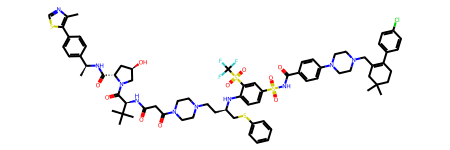

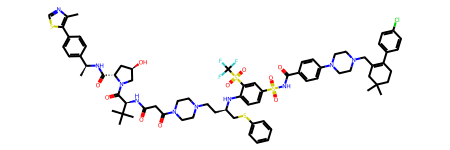

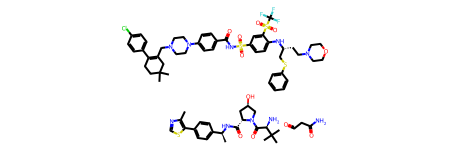

In [78]:
def same_atom_counts_and_types(
        smiles1: str,
        smiles2: str,
        get_atoms_diff: bool = False,
) -> bool | Dict[str, int]:
    """
    Check if two molecules have the same number and types of atoms.

    Args:
        smiles1 (str): SMILES notation for the first molecule.
        smiles2 (str): SMILES notation for the second molecule.
        get_atoms_diff (bool, optional): If True, returns the difference in atom counts. If False, returns if they match. Defaults to False.

    Returns:
        bool: True if the molecules have the same atom counts and types, False otherwise.
    """
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)
    if mol1 is None or mol2 is None:
        if get_atoms_diff:
            raise ValueError("Invalid SMILES notation provided for one or both molecules.")
        else:
            return False
    atom_counts1, atom_counts2 = {}, {}
    for atom in mol1.GetAtoms():
        if '*' not in atom.GetSmarts():
            atom_counts1[atom.GetSymbol()] = atom_counts1.get(atom.GetSymbol(), 0) + 1
    for atom in mol2.GetAtoms():
        if '*' not in atom.GetSmarts():
            atom_counts2[atom.GetSymbol()] = atom_counts2.get(atom.GetSymbol(), 0) + 1
    # atom_counts1 = {atom.GetSymbol(): atom.GetIdx() for atom in mol1.GetAtoms()}
    # atom_counts2 = {atom.GetSymbol(): atom.GetIdx() for atom in mol2.GetAtoms()}
    if get_atoms_diff:
        tmp = {}
        for atom in atom_counts1.keys():
            tmp[atom] = int(abs(atom_counts1.get(atom, 0) - atom_counts2.get(atom, 0)))
        for atom in atom_counts2.keys():
            tmp[atom] = int(abs(atom_counts1.get(atom, 0) - atom_counts2.get(atom, 0)))
        return tmp # abs(atom_counts1.get('O', 0) - atom_counts2.get('O', 0))
    else:
        num_atoms1 = Chem.rdMolDescriptors.CalcNumHeavyAtoms(mol1)
        num_atoms2 = Chem.rdMolDescriptors.CalcNumHeavyAtoms(mol2)
        return (atom_counts1 == atom_counts2) & (num_atoms1 == num_atoms2)

x = protac_pedia_df.iloc[0]
oxygen_diff = same_atom_counts_and_types(
    x['PROTAC SMILES'],
    '.'.join([x['E3 Binder SMILES'], x['Linker SMILES'], x['POI Ligand SMILES']]),
    get_atoms_diff=True,
)
print(oxygen_diff)
safe_display(Chem.MolFromSmiles(x['PROTAC SMILES']))
safe_display(Chem.MolFromSmiles(x['PROTAC SMILES']))
safe_display(Chem.MolFromSmiles('.'.join([x['E3 Binder SMILES'], x['Linker SMILES'], x['POI Ligand SMILES']])))

## Substructure Search (Improved Version)

The following should be a more streamlined version of the substructure search function.

STILL A WORK IN PROGRESS. But it is promising...

POI: [*:1]CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(=O)Nc4cc(Cl)ccc43)[C@H]2c2cccc(Cl)c2F)cc1
POI: [1*]CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(=O)Nc4cc(Cl)ccc43)[C@H]2c2cccc(Cl)c2F)cc1


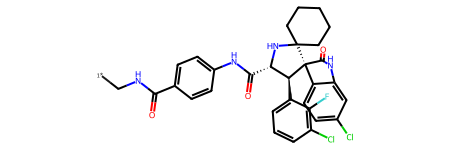

E3: [*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
E3: [2*]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O


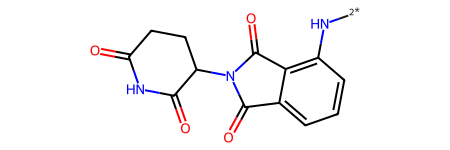

Linker: [*:2]CCC[*:1]
Linker: [1*]CCC[2*]


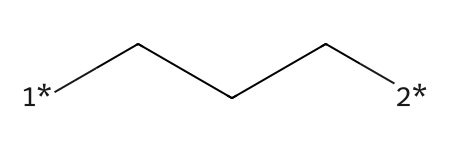

In [108]:
tmp = {
    'PROTAC SMILES': 'O=C1CCC(N2C(=O)c3cccc(NCCCCNC(=O)c4ccc(NC(=O)[C@@H]5NC6(CCCCC6)[C@@]6(C(=O)Nc7cc(Cl)ccc76)[C@H]5c5cccc(Cl)c5F)cc4)c3C2=O)C(=O)N1',
    'E3 Binder SMILES': 'Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O',
    'Linker SMILES': 'CCC',
    'POI Ligand SMILES': 'CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(=O)Nc4cc(Cl)ccc43)[C@H]2c2cccc(Cl)c2F)cc1',
    'E3 Binder SMILES with direction': '[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O',
    'Linker SMILES with direction': '[*:2]CCC[*:1]',
    'POI Ligand SMILES with direction': '[*:1]CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(=O)Nc4cc(Cl)ccc43)[C@H]2c2cccc(Cl)c2F)cc1',
}
protac_smiles = tmp['PROTAC SMILES']
e3_smiles = tmp['E3 Binder SMILES']
linker_smiles = tmp['Linker SMILES']
poi_smiles = tmp['POI Ligand SMILES']

def get_attachment_bonds(mol, match_atoms) -> List[int]:
    """ Get the bonds to break to separate the substructure from the PROTAC or R-groups molecule.
    
    Args:
        mol: The molecule to break.
        match_atoms: The atoms matched in the molecule, from the GetSubstructMatch function.
    
    Returns:
        List[int]: The bond indices to break.
    """
    bonds_to_break = []
    for idx in match_atoms:
        atom = mol.GetAtomWithIdx(idx)
        for bond in atom.GetBonds():
            neighbor_idx = bond.GetOtherAtomIdx(idx)
            if neighbor_idx not in match_atoms:
                bonds_to_break.append(bond.GetIdx())
    return bonds_to_break

mol_protac = Chem.MolFromSmiles(protac_smiles)
mol_poi = Chem.MolFromSmiles(poi_smiles)
mol_e3 = Chem.MolFromSmiles(e3_smiles)
mol_linker = Chem.MolFromSmiles(linker_smiles)

poi_match = mol_protac.GetSubstructMatch(mol_poi)

# Get bonds to break to separate the POI ligand
bonds_to_break_poi = get_attachment_bonds(mol_protac, poi_match)

# Break the bonds to isolate the POI ligand
frag_mol_poi = Chem.FragmentOnBonds(mol_protac, bonds_to_break_poi, addDummies=True, dummyLabels=[(POI_ATTACHMENT_ID, POI_ATTACHMENT_ID)])

# Get the fragments resulting from bond breaking
frags = Chem.GetMolFrags(frag_mol_poi, asMols=True, sanitizeFrags=True)

# Identify the POI ligand fragment
for frag in frags:
    if frag.HasSubstructMatch(mol_poi):
        poi_fragment = frag
        break

# Combine the remaining fragments to get the R-groups
# TODO: Check that the length of frags is 1, otherwise, there are multiple fragments
r_group_mol = [frag for frag in frags if frag != poi_fragment][0]

print('POI:', tmp['POI Ligand SMILES with direction'])
print('POI:', Chem.MolToSmiles(poi_fragment, canonical=True))
safe_display(poi_fragment)

e3_match = r_group_mol.GetSubstructMatch(mol_e3)

# Get bonds to break to isolate the E3 binder
bonds_to_break_e3 = get_attachment_bonds(r_group_mol, e3_match)

# Break the bonds to isolate the E3 binder
frag_mol_e3 = Chem.FragmentOnBonds(r_group_mol, bonds_to_break_e3, addDummies=True, dummyLabels=[(E3_ATTACHMENT_ID, E3_ATTACHMENT_ID)])

# Get fragments after breaking bonds in R-groups
frags = Chem.GetMolFrags(frag_mol_e3, asMols=True, sanitizeFrags=True)

# Identify the E3 binder fragment
for frag in frags:
    if frag.HasSubstructMatch(mol_e3):
        e3_fragment = frag
        break

print('E3:', tmp['E3 Binder SMILES with direction'])
print('E3:', Chem.MolToSmiles(e3_fragment, canonical=True))
safe_display(e3_fragment)

# The remaining fragment is the linker
# TODO: Check that the length of frags is 1, otherwise, there are multiple fragments
linker_mol = [frag for frag in frags if frag != e3_fragment][0]

print('Linker:', tmp['Linker SMILES with direction'])
print('Linker:', Chem.MolToSmiles(linker_mol, canonical=True))
safe_display(linker_mol)

## Substructure Search

In [79]:
def remove_bond_attachments(smiles):
    smiles = smiles.replace(f'[*:{POI_ATTACHMENT_ID}]=', f'[*:{POI_ATTACHMENT_ID}]')
    smiles = smiles.replace(f'[*:{POI_ATTACHMENT_ID}]#', f'[*:{POI_ATTACHMENT_ID}]')

    smiles = smiles.replace(f'[*:{E3_ATTACHMENT_ID}]=', f'[*:{E3_ATTACHMENT_ID}]')
    smiles = smiles.replace(f'[*:{E3_ATTACHMENT_ID}]#', f'[*:{E3_ATTACHMENT_ID}]')

    smiles = smiles.replace(f'=[*:{POI_ATTACHMENT_ID}]', f'[*:{POI_ATTACHMENT_ID}]')
    smiles = smiles.replace(f'#[*:{POI_ATTACHMENT_ID}]', f'[*:{POI_ATTACHMENT_ID}]')

    smiles = smiles.replace(f'=[*:{E3_ATTACHMENT_ID}]', f'[*:{E3_ATTACHMENT_ID}]')
    smiles = smiles.replace(f'#[*:{E3_ATTACHMENT_ID}]', f'[*:{E3_ATTACHMENT_ID}]')
    
    return smiles


def remove_attachment_points(smiles: str) -> str:
    """
    Remove attachment points labeled as "[*:1]" or "[*:2]" from a molecule represented by SMILES.

    Args:
        smiles (str): The SMILES notation of the molecule.

    Returns:
        str: SMILES notation of the molecule with attachment points removed.
    """
    # TODO: Barely removing the attachment points can result in
    # invalid SMILES... Why?
    smiles = remove_bond_attachments(smiles)
    return smiles.replace(f"[*:{POI_ATTACHMENT_ID}]", "").replace(f"[*:{E3_ATTACHMENT_ID}]", "")


def add_e3_poi_directionality_v2(row: pd.Series) -> pd.Series:
    """ This gets both E3 and POI with attachment points.
    
    Args:
        row (pd.Series): A row from a DataFrame.

    Returns:
        pd.Series: The same row with the E3 and POI ligands with attachment points
    """
    # Set default values
    e3_smiles_dir = float('nan')
    poi_smiles_dir = float('nan')
    row['E3 Binder SMILES with direction'] = e3_smiles_dir
    row['POI Ligand SMILES with direction'] = poi_smiles_dir

    # Get the molecules
    protac_mol = Chem.MolFromSmiles(row['PROTAC SMILES'])
    poi_mol = Chem.MolFromSmiles(row['POI Ligand SMILES'])
    e3_mol = Chem.MolFromSmiles(row['E3 Binder SMILES'])
    linker_mol = Chem.MolFromSmarts(row['Linker SMILES'])

    # If any of the above is None, return the row as is
    if any([protac_mol is None, poi_mol is None, e3_mol is None, linker_mol is None]):
        return row

    # Remove the E3 and POI ligands from the PROTAC molecule to get the R-groups
    rgroups_linker_poi_mol = Chem.DeleteSubstructs(protac_mol, e3_mol)
    rgroups_linker_e3_mol = Chem.DeleteSubstructs(protac_mol, poi_mol)

    e3_mol_dir = Chem.ReplaceCore(protac_mol, rgroups_linker_poi_mol, labelByIndex=False, replaceDummies=False)
    poi_mol_dir = Chem.ReplaceCore(protac_mol, rgroups_linker_e3_mol, labelByIndex=False, replaceDummies=False)

    # Add attachment points to the E3 ligand
    e3_smiles_dir = Chem.MolToSmiles(e3_mol_dir, canonical=True)
    # Remove the linker from the R-groups instead
    if len(e3_smiles_dir.split(".")) > 2 or len(e3_smiles_dir.split("*")) > 2:
        e3_mol_dir = Chem.ReplaceCore(rgroups_linker_e3_mol, linker_mol, labelByIndex=False, replaceDummies=False)
        if len(e3_smiles_dir.split(".")) > 2:
            # print(f'ERROR: E3 has multiple substructures: {e3_smiles_dir}')
            return row
        if len(e3_smiles_dir.split("*")) > 2:
            # print(f'ERROR: E3 has multiple attachment points: {e3_smiles_dir}')
            return row
        
    for i, substruct_smiles in enumerate(e3_smiles_dir.split(".")):
        substruct_mol = Chem.MolFromSmiles(substruct_smiles, sanitize=True)
        if not substruct_mol:
            return row

        if substruct_mol.HasSubstructMatch(e3_mol):
            e3_smiles_dir = substruct_smiles.replace(f'[{i+1}*]', f'[*:{E3_ATTACHMENT_ID}]')
            break

    # Add attachment points to the POI ligand
    poi_smiles_dir = Chem.MolToSmiles(poi_mol_dir, canonical=True)
    # Remove the linker from the R-groups instead
    if len(e3_smiles_dir.split(".")) > 2 or len(e3_smiles_dir.split("*")) > 2:
        poi_mol_dir = Chem.ReplaceCore(rgroups_linker_poi_mol, linker_mol, labelByIndex=False, replaceDummies=False)
        if len(poi_smiles_dir.split(".")) > 2:
            # print(f'ERROR: POI has multiple substructures: {poi_smiles_dir}')
            return row
        if len(poi_smiles_dir.split("*")) > 2:
            # print(f'ERROR: POI has multiple attachment points: {poi_smiles_dir}')
            return row

    for i, substruct_smiles in enumerate(poi_smiles_dir.split(".")):
        substruct_mol = Chem.MolFromSmiles(substruct_smiles, sanitize=True)
        if not substruct_mol:
            poi_smiles_dir = float('nan')
            safe_display(protac_mol)
            safe_display(poi_mol)
            safe_display(linker_mol)
            safe_display(e3_mol)
            print(f'poi smiles:   {row["POI Ligand SMILES"]}')
            print(f'poi modified: {substruct_smiles}')
            print('=' * 80)
        else:
            if substruct_mol.HasSubstructMatch(poi_mol):
                poi_smiles_dir = substruct_smiles.replace(f'[{i+1}*]', f'[*:{POI_ATTACHMENT_ID}]')
                break

    # Set the output fields
    row['E3 Binder SMILES with direction'] = e3_smiles_dir
    row['POI Ligand SMILES with direction'] = poi_smiles_dir

    return row


def reset_row(
        row: pd.Series,
        how: Literal['all', 'poi', 'e3', 'linker'] = 'all',
) -> pd.Series:
    """ Reset the row to the original values.

    Args:
        row (pd.Series): A row from a DataFrame.

    Returns:
        pd.Series: The same row with the E3 and POI ligands with attachment points
    """
    if how == 'poi' or how == 'all':
        row['POI Ligand ID'] = float('nan')
        row['POI Ligand SMILES'] = float('nan')
        row['POI Ligand SMILES with direction'] = float('nan')
    if how == 'e3' or how == 'all':
        row['E3 Binder ID'] = float('nan')
        row['E3 Binder SMILES'] = float('nan')
        row['E3 Binder SMILES with direction'] = float('nan')
    if how == 'linker' or how == 'all':
        row['Linker ID'] = float('nan')
        row['Linker SMILES'] = float('nan')
        row['Linker SMILES with direction'] = float('nan')
    row['poi_exact_match'] = False
    row['e3_exact_match'] = False
    return row


def dummy2query(mol: Chem.Mol) -> Chem.Mol:
    """ Converts dummy atoms to query atoms, so that a molecule with attachment points can be used in HasSubstructMatch.
    
    Args:
        mol: The molecule to convert.

    Returns:
        The molecule with dummy atoms converted to query atoms
    """
    if mol is None:
        return None
    p = Chem.AdjustQueryParameters.NoAdjustments()
    p.makeDummiesQueries = True
    return Chem.AdjustQueryProperties(mol, p)


# TODO: Collect more advanced statistics, like the SMILES, et cetera...
from collections import Counter

stats = Counter()
failed_protacs = []

def get_substructures_from_dict(
        row: pd.Series,
        poi_dict: pd.DataFrame,
        e3_dict: pd.DataFrame,
) -> pd.Series:
    """ Get the substructures of a PROTAC from the dictionaries.
    
    Args:
        row (pd.Series): A row from the PROTAC-Pedia DataFrame.
        poi_dict (pd.DataFrame): The dictionary of POI ligands.
        e3_dict (pd.DataFrame): The dictionary of E3 binders.
    
    Returns:
        pd.Series: The row with the substructures added.
    """
    # The algorithm is as follows:
    # 1. Given the molecule of the PROTAC, try to match a POI from the POI dictionary first.
    # 2. If the POI is found, get the R-groups, i.e., the E3 and linker together.
    # 3. If the E3 from the E3 dictionary is found in the R-groups, get the linker as the remaining part.

    # Set default values
    row = reset_row(row)

    protac_smiles = row["PROTAC SMILES"]
    protac_mol = row["PROTAC Molecule"]
    rgroups_smiles = ""

    # --------------------------------------------------------------------------
    # NOTE: The following is an attempt of using the linker matches to get the R-groups...
    # --------------------------------------------------------------------------
    # linker_matches = linker_dict["Molecule"].apply(lambda linker: protac_mol.HasSubstructMatch(linker))
    # # Sort the Linker matches by the number of atoms in the molecule
    # if linker_matches.any():
    #     linker_matches = linker_dict[linker_matches]
    #     linker_matches = linker_matches.sort_values(by="Molecule", key=lambda s: s.apply(lambda m: m.GetNumAtoms()))
    #
    #     for _, row_l in linker_matches.iterrows():
    #         linker_mol = row_l["Molecule"]
    #         rgroups_mol = Chem.ReplaceCore(protac_mol, linker_mol, protac_mol.GetSubstructMatch(linker_mol), labelByIndex=False)
    #
    #         e3_poi_mol = Chem.GetMolFrags(rgroups_mol, asMols=True)
    #         if len(e3_poi_mol) != 2:
    #             continue
    #         else:
    #             e3_mol, poi_mol = e3_poi_mol
    #             e3_mol_dir = Chem.ReplaceSidechains(protac_mol, e3_mol, useChirality=True)
    #             poi_mol_dir = Chem.ReplaceSidechains(protac_mol, poi_mol, useChirality=True)
    #             print(Chem.MolToSmiles(e3_mol_dir, canonical=True))
    #             print(Chem.MolToSmiles(poi_mol_dir, canonical=True))
    #             break
    # --------------------------------------------------------------------------

    # Get all the POIs and E3s that are substructure matches of the PROTAC
    poi_matches = poi_dict['POI Ligand Molecule'].apply(lambda poi: protac_mol.HasSubstructMatch(poi))
    poi_matches = poi_dict[poi_matches]
    if poi_matches.empty:
        stats['no_poi_match'] += 1
        failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'no_poi_match'})
        return row
    e3_matches = e3_dict['E3 Binder Molecule'].apply(lambda e3: protac_mol.HasSubstructMatch(e3))
    e3_matches = e3_dict[e3_matches]
    if e3_matches.empty:
        stats['no_e3_match'] += 1
        failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'no_e3_match'})
        return row
    
    def is_dangling(mol):
        """ This function is used to filter out matches of "small" substructures,
        for which the GetSubstructMatch would return more than one fragment.
        """
        return len(Chem.GetMolFrags(Chem.ReplaceCore(protac_mol, mol, protac_mol.GetSubstructMatch(mol), labelByIndex=False))) != 1
    
    non_dangling = poi_matches['POI Ligand Molecule'].apply(lambda poi: not is_dangling(poi))
    poi_matches = poi_matches[non_dangling]
    if poi_matches.empty:
        stats['poi_dangling_groups'] += 1
        failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'poi_dangling_groups'})
        return row
    
    non_dangling = e3_matches['E3 Binder Molecule'].apply(lambda e3: not is_dangling(e3))
    e3_matches = e3_matches[non_dangling]
    if e3_matches.empty:
        stats['e3_dangling_groups'] += 1
        failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'e3_dangling_groups'})
        return row

    row['poi_exact_match'] = True
    row['e3_exact_match'] = True

    # Sort the matches by the number of atoms in the molecule
    poi_matches = poi_matches.sort_values(by='POI Ligand Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=False)
    e3_matches = e3_matches.sort_values(by='E3 Binder Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=False)

    # Flag to stop the outer POI-loop if the inner E3-loop succeeded
    all3_matching = False

    for _, row_p in poi_matches.iterrows():
        # First check that the POI is a perfect match with no "dangling" groups
        poi_mol = row_p['POI Ligand Molecule']
        rgroups_mol = Chem.ReplaceCore(protac_mol, poi_mol, protac_mol.GetSubstructMatch(poi_mol), labelByIndex=False)
        if len(Chem.GetMolFrags(rgroups_mol)) != 1:
            row = reset_row(row)
            stats['poi_dangling_groups'] += 1
            failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'poi_dangling_groups'})
            continue

        rgroups_smiles = Chem.MolToSmiles(rgroups_mol, canonical=True)

        # Extra check the R-group SMILES: if there are 'floating' groups, i.e.,
        # non perfect matches, then go to the next POI match.
        if len(rgroups_smiles.split('*')) != 2:
            row = reset_row(row)
            stats['multiple * in R-Group=PROTAC-POI'] += 1
            failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'multiple * in R-Group=PROTAC-POI'})
            continue

        rgroups_smiles = rgroups_smiles.replace('[1*]', f'[*:{POI_ATTACHMENT_ID}]')
        rgroups_mol = Chem.MolFromSmiles(rgroups_smiles)

        # Extract the E3 Binders that are a substructure match in R-groups
        # NOTE: Do the search here, so that "quick checks" can be done before
        # e3_matches = e3_dict['E3 Binder Molecule'].apply(lambda e3: protac_mol.HasSubstructMatch(e3))
        # e3_matches = e3_dict[e3_matches]
        # if e3_matches.empty:
        #     row = reset_row(row)
        #     continue
        # # Sort the E3 matches by the number of atoms in the molecule
        # e3_matches = e3_matches.sort_values(by='E3 Binder Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=False)

        # Set the POI based on the found one
        row['POI Ligand ID'] = row_p['POI Ligand ID']
        row['POI Ligand SMILES'] = Chem.MolToSmiles(poi_mol, canonical=True)

        for _, row_e in e3_matches.iterrows():
            e3_mol = row_e['E3 Binder Molecule']

            # Check that the R-group (= PROTAC - POI) also 
            if not rgroups_mol.HasSubstructMatch(e3_mol):
                row = reset_row(row, how='e3')
                stats['rgroup_not_match_e3'] += 1
                failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'rgroup_not_match_e3'})
                continue

            # linker_mol = Chem.ReplaceCore(rgroups_mol, e3_mol, labelByIndex=False, replaceDummies=False) # Original
            linker_mol = Chem.ReplaceCore(rgroups_mol, e3_mol, dummy2query(rgroups_mol).GetSubstructMatch(e3_mol), labelByIndex=False, replaceDummies=False)

            if linker_mol is None:
                row = reset_row(row, how='e3')
                stats['linker_invalid'] += 1
                failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'linker_invalid'})
                continue

            # # Get the linker from the E3 and R-groups
            # linker_mol = Chem.ReplaceCore(rgroups_mol, e3_mol, rgroups_mol.GetSubstructMatch(e3_mol), labelByIndex=False)
            # if linker_mol is None:
            #     # linker_mol = Chem.ReplaceSidechains(rgroups_mol, e3_mol) # Original
            #     linker_mol = Chem.ReplaceSidechains(rgroups_mol, e3_mol, useChirality=True)
            #     # linker_mol = Chem.ReplaceCore(rgroups_mol, e3_mol, labelByIndex=False)
            #     if linker_mol is None:
            #         continue

            linker_smiles = Chem.MolToSmiles(linker_mol, canonical=True)

            # If there are 'floating' groups other than the linker, continue
            if '.' in linker_smiles:
                row = reset_row(row, how='e3')
                stats['multiple_linker_substructures'] += 1
                failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'multiple_linker_substructures'})
                continue

            linker_smiles = linker_smiles.replace('[1*]', f'[*:{E3_ATTACHMENT_ID}]')

            # # if not protac_mol.HasSubstructMatch(Chem.MolFromSmarts(linker_smiles)):
            # linker_as_query = dummy2query(Chem.MolFromSmiles(linker_smiles))
            # if linker_as_query is not None:
            #     if not protac_mol.HasSubstructMatch(linker_as_query):
            #         row = reset_row(row, how='e3')
            #         stats['linker_not_match_protac'] += 1
            # failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'linker_not_match_protac'})
            #         continue

            # Get attachment points for the E3 and POI ligands
            e3_mol_dir = Chem.ReplaceSidechains(rgroups_mol, e3_mol, useChirality=True)
            poi_mol_dir = Chem.ReplaceSidechains(protac_mol, poi_mol, useChirality=True)

            # Try a more advanced method to get the attachment points
            # NOTE: It requires the current substructures' SMILES to be set.
            row['POI Ligand SMILES'] = Chem.MolToSmiles(poi_mol, canonical=True)
            row['E3 Binder SMILES'] = Chem.MolToSmiles(e3_mol, canonical=True)
            row['Linker SMILES'] = linker_smiles

            if pd.isnull(e3_mol_dir) or pd.isnull(poi_mol_dir):
                row = add_e3_poi_directionality_v2(row.copy())
                
                if pd.isnull(row['E3 Binder SMILES with direction']) or pd.isnull(row['POI Ligand SMILES with direction']):
                    row = reset_row(row, how='e3')
                    row = reset_row(row, how='linker')
                    stats['advanced_directionality_failed'] += 1
                    failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'advanced_directionality_failed'})
                    continue

                e3_mol_dir = Chem.MolFromSmiles(row['E3 Binder SMILES with direction'])
                poi_mol_dir = Chem.MolFromSmiles(row['POI Ligand SMILES with direction'])

                if pd.isnull(e3_mol_dir) or pd.isnull(poi_mol_dir):
                    row = reset_row(row, how='e3')
                    row = reset_row(row, how='linker')
                    stats['mol from advanced_directionality are invalid'] += 1
                    failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'mol from advanced_directionality are invalid'})
                    continue

            row['E3 Binder SMILES with direction'] = Chem.MolToSmiles(e3_mol_dir, canonical=True).replace('[1*]', f'[*:{E3_ATTACHMENT_ID}]')
            row['POI Ligand SMILES with direction'] = Chem.MolToSmiles(poi_mol_dir, canonical=True).replace('[1*]', f'[*:{POI_ATTACHMENT_ID}]')

            # Check that there are no more than one '*' in the POI ligand SMILES
            if row['POI Ligand SMILES with direction'].count('*') > 1:
                row = reset_row(row)
                stats['poi_multiple_attachment_points'] += 1
                failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'poi_multiple_attachment_points'})
                continue

            # Check that there are no more than one '*' in the E3 binder SMILES
            if row['E3 Binder SMILES with direction'].count('*') > 1:
                row = reset_row(row, how='e3')
                stats['e3_multiple_attachment_points'] += 1
                failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'e3_multiple_attachment_points'})
                continue

            # Set the other fields in the row
            row['POI Ligand ID'] = row_p['POI Ligand ID']
            row['E3 Binder ID'] = row_e['E3 Binder ID']
            row['Linker SMILES with direction'] = linker_smiles
            row['Linker SMILES'] = remove_attachment_points(linker_smiles)

            # ------------------------------------------------------------------
            # # Final check on the reassembled PROTAC
            # is_reassembled = check_substructs(
            #     protac_smiles=protac_smiles,
            #     poi_smiles=row['POI Ligand SMILES with direction'],
            #     linker_smiles=row['Linker SMILES with direction'],
            #     e3_smiles=row['E3 Binder SMILES with direction'],
            # )
            # ------------------------------------------------------------------

            substructs_smiles = f"{row['E3 Binder SMILES with direction']}.{row['Linker SMILES with direction']}.{row['POI Ligand SMILES with direction']}"
            substructs_mol = Chem.MolFromSmiles(substructs_smiles, sanitize=True)
            if substructs_mol is None:
                row = reset_row(row, how='e3')
                row = reset_row(row, how='linker')
                stats['invalid_substructs'] += 1
                failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'invalid_substructs'})
                continue
            try:
                reassembled_mol = Chem.molzip(substructs_mol)
            except:
                reassembled_mol = None
            if reassembled_mol is None:
                row = reset_row(row, how='e3')
                row = reset_row(row, how='linker')
                stats['reassembled_failed'] += 1
                failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'reassembled_failed'})
                continue

            reassembled_smiles = Chem.MolToSmiles(reassembled_mol, canonical=True)
            is_reassembled = reassembled_smiles == row['PROTAC SMILES']
            # ------------------------------------------------------------------

            if not is_reassembled:
                row = reset_row(row, how='e3')
                row = reset_row(row, how='linker')
                stats['not_reassembled'] += 1
                failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'not_reassembled'})
                continue

            # Update the linker dictionary if not there
            if row['Linker SMILES'] not in smiles2id_dict['Linker']:
                smiles2id_dict['Linker'][row['Linker SMILES']] = len(smiles2id_dict['Linker'])
            row['Linker SMILES ID'] = smiles2id_dict['Linker'][row['Linker SMILES']]

            all3_matching = True
            break

        # If all 3 components are matching, break the outer POI loop as well and
        # return the updated row with the found matches
        if all3_matching:
            break

    return row


smi_cols = ['E3 Binder SMILES', 'Linker SMILES', 'POI Ligand SMILES']
dir_cols = [f'{s} with direction' for s in smi_cols]

poi_dict = smiles2id_df['POI Ligand']
e3_dict = smiles2id_df['E3 Binder']

# NOTE: Remove the duplicates later by keeping the largest substructures

# ------------------------------------------------------------------------------

# pedia = protac_pedia_df.drop_duplicates(subset=['PROTAC SMILES'])
# db = protac_db_df.drop_duplicates(subset=['PROTAC SMILES'])
# protac_curated_df = pd.concat([db, pedia], axis=0, ignore_index=True)
# protac_curated_df = protac_curated_df.drop_duplicates(subset=['PROTAC SMILES'])

# tqdm.pandas(desc='Get substructures', postfix=None)
# protac_curated_df = protac_curated_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
# protac_curated_df = protac_curated_df.dropna(subset=smi_cols)

# ------------------------------------------------------------------------------

print(f'Length of PROTAC-Pedia: {len(protac_pedia_df)}')
tqdm.pandas(desc='Get substructures for PROTAC-Pedia', postfix=None)
pedia = protac_pedia_df.drop_duplicates(subset=['PROTAC SMILES'])
pedia = pedia.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
pedia = pedia.dropna(subset=smi_cols)
print(f'Length of PROTAC-Pedia: {len(pedia)} (after substructure matching)')

# Print the statistics and then reset the counter
print('-' * 80)
for k, v in stats.items():
    print(f'{k}: {v}')
stats.clear()
print('-' * 80)

if len(pedia) == 0:
    raise ValueError('No PROTAC-Pedia entries were matched with the dictionaries.')

print('')

print(f'Length of PROTAC-DB: {len(protac_db_df)}')
tqdm.pandas(desc='Get substructures for PROTAC-DB', postfix=None)
db = protac_db_df.drop_duplicates(subset=['PROTAC SMILES'])
db = db.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
db = db.dropna(subset=smi_cols)
print(f'Length of PROTAC-DB: {len(db)} (after substructure matching)')

# NOTE: protac_pedia_curated_df is the DataFrame with the curated PROTAC-Pedia
# entries that matched already with its entries
protac_curated_df = pd.concat([db, pedia], axis=0, ignore_index=True)
protac_curated_df = protac_curated_df.dropna(subset=dir_cols)

# Print the statistics and then reset the counter
print('-' * 80)
for k, v in stats.items():
    print(f'{k}: {v}')
stats.clear()
print('-' * 80)

# ------------------------------------------------------------------------------

# safe_display(protac_curated_df[smi_cols].head())
# safe_display(protac_curated_df[dir_cols].head())
print(f'Length of PROTAC-Curated: {len(protac_curated_df)}')

failed_protacs_df = pd.DataFrame(failed_protacs).drop_duplicates(subset=['PROTAC SMILES'])
failed_protacs_df.head()

Length of PROTAC-Pedia: 1203


Get substructures for PROTAC-Pedia: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1178/1178 [00:18<00:00, 62.61it/s]


Length of PROTAC-Pedia: 725 (after substructure matching)
--------------------------------------------------------------------------------
poi_dangling_groups: 67
poi_multiple_attachment_points: 26
e3_multiple_attachment_points: 172
no_poi_match: 310
no_e3_match: 5
advanced_directionality_failed: 78
multiple * in R-Group=PROTAC-POI: 40
reassembled_failed: 7
e3_dangling_groups: 5
rgroup_not_match_e3: 12
not_reassembled: 53
--------------------------------------------------------------------------------

Length of PROTAC-DB: 5388


Get substructures for PROTAC-DB: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3270/3270 [00:48<00:00, 67.56it/s]


Length of PROTAC-DB: 1691 (after substructure matching)
--------------------------------------------------------------------------------
multiple * in R-Group=PROTAC-POI: 53
no_e3_match: 48
no_poi_match: 1099
e3_dangling_groups: 33
poi_dangling_groups: 265
reassembled_failed: 13
advanced_directionality_failed: 75
e3_multiple_attachment_points: 272
rgroup_not_match_e3: 52
not_reassembled: 259
poi_multiple_attachment_points: 1
--------------------------------------------------------------------------------
Length of PROTAC-Curated: 2416


,PROTAC SMILES,error
0,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,linker_not_match_protac
1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,linker_not_match_protac
2,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,linker_not_match_protac
3,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,linker_not_match_protac
4,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,linker_not_match_protac


```
Length of PROTAC-Pedia: 1203
Get substructures for PROTAC-Pedia: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1178/1178 [00:18<00:00, 62.78it/s]
Length of PROTAC-Pedia: 723 (after substructure matching)
--------------------------------------------------------------------------------
poi_dangling_groups: 67
poi_multiple_attachment_points: 26
e3_multiple_attachment_points: 170
no_poi_match: 312
no_e3_match: 5
advanced_directionality_failed: 78
multiple * in R-Group=PROTAC-POI: 40
reassembled_failed: 7
e3_dangling_groups: 5
rgroup_not_match_e3: 12
not_reassembled: 53
--------------------------------------------------------------------------------

Length of PROTAC-DB: 5388
Get substructures for PROTAC-DB: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3270/3270 [00:47<00:00, 69.47it/s]
Length of PROTAC-DB: 1684 (after substructure matching)
--------------------------------------------------------------------------------
multiple * in R-Group=PROTAC-POI: 53
no_e3_match: 48
no_poi_match: 1109
e3_dangling_groups: 32
poi_dangling_groups: 263
reassembled_failed: 13
advanced_directionality_failed: 75
e3_multiple_attachment_points: 268
rgroup_not_match_e3: 52
not_reassembled: 241
poi_multiple_attachment_points: 1
--------------------------------------------------------------------------------
Length of PROTAC-Curated: 2407
```

**NOTE**: the duplicates in the dataframes are not removed according to their substructures (with direction). The reason is that there might be _different PROTACs_ for which the _same_ substructures are used, but linked together with _different bonds_.

Error type: linker_not_match_protac
Number of PROTACs with this error: 2,046


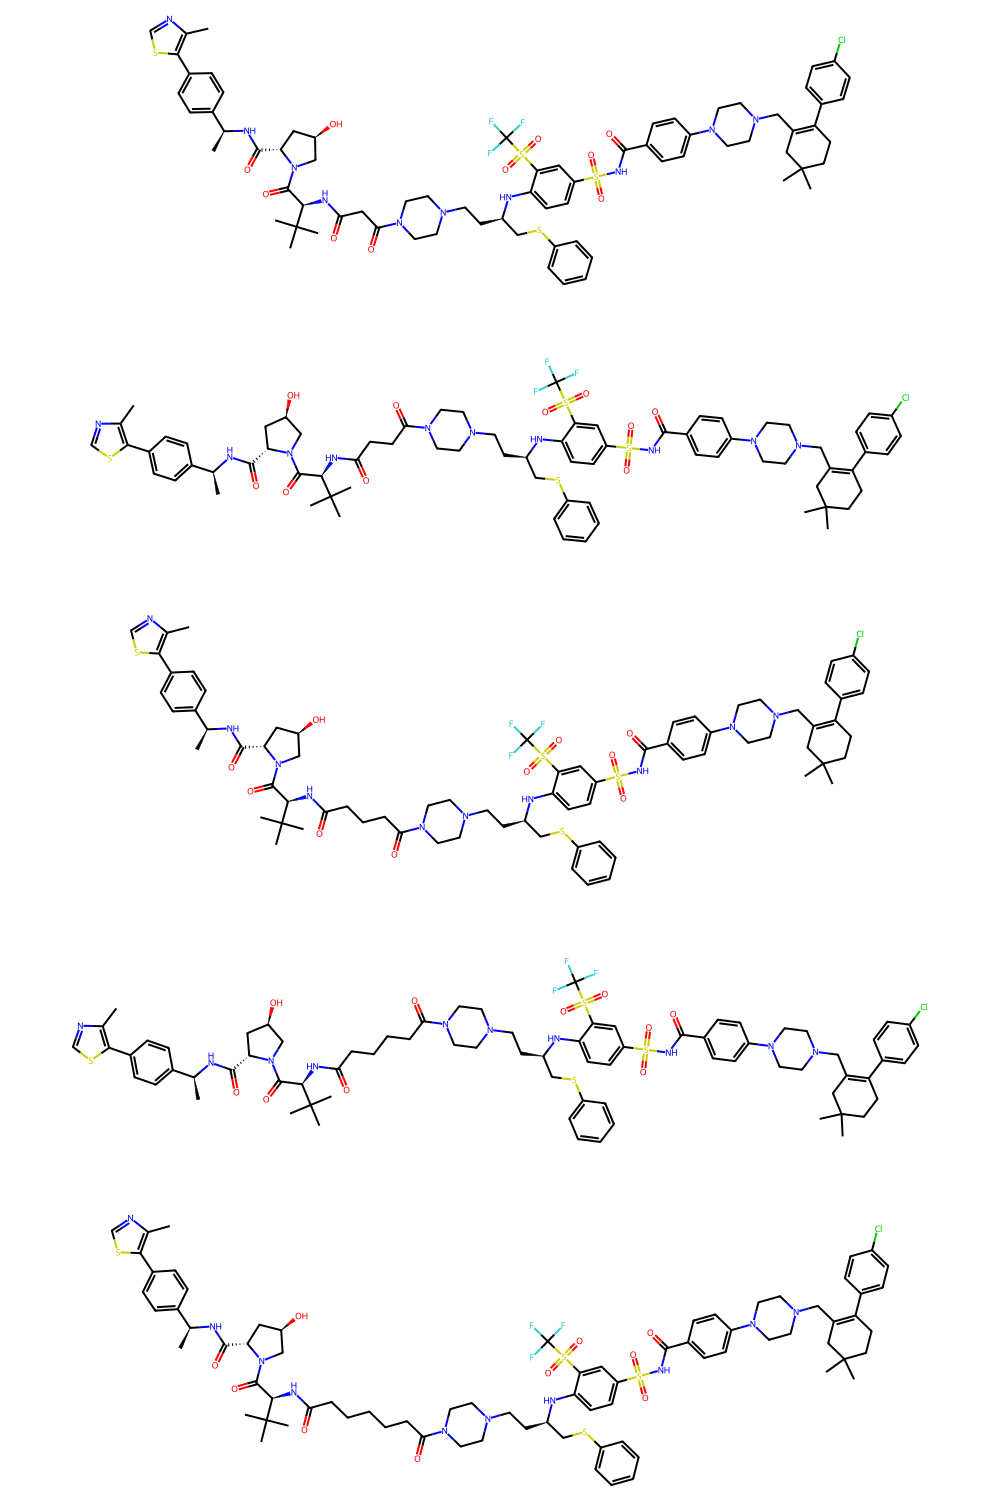

Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc3)Nc3ccc(S(=O)(=O)NC(=O)c4ccc(N5CCN(CC6=C(c7ccc(Cl)cc7)CCC(C)(C)C6)CC5)cc4)cc3S(=O)(=O)C(F)(F)F)CC2)C(C)(C)C)cc1
Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCC(=O)N2CCN(CC[C@H](CSc3ccccc3)Nc3ccc(S(=O)(=O)NC(=O)c4ccc(N5CCN(CC6=C(c7ccc(Cl)cc7)CCC(C)(C)C6)CC5)cc4)cc3S(=O)(=O)C(F)(F)F)CC2)C(C)(C)C)cc1
Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCC(=O)N2CCN(CC[C@H](CSc3ccccc3)Nc3ccc(S(=O)(=O)NC(=O)c4ccc(N5CCN(CC6=C(c7ccc(Cl)cc7)CCC(C)(C)C6)CC5)cc4)cc3S(=O)(=O)C(F)(F)F)CC2)C(C)(C)C)cc1
Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCC(=O)N2CCN(CC[C@H](CSc3ccccc3)Nc3ccc(S(=O)(=O)NC(=O)c4ccc(N5CCN(CC6=C(c7ccc(Cl)cc7)CCC(C)(C)C6)CC5)cc4)cc3S(=O)(=O)C(F)(F)F)CC2)C(C)(C)C)cc1
Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCC(=O)N2CCN(CC[C@H](CSc3ccccc3)Nc3ccc(S(=O)(=O)NC(=O)c4ccc(N5CCN(CC6=C(c7ccc(Cl)cc7)CCC

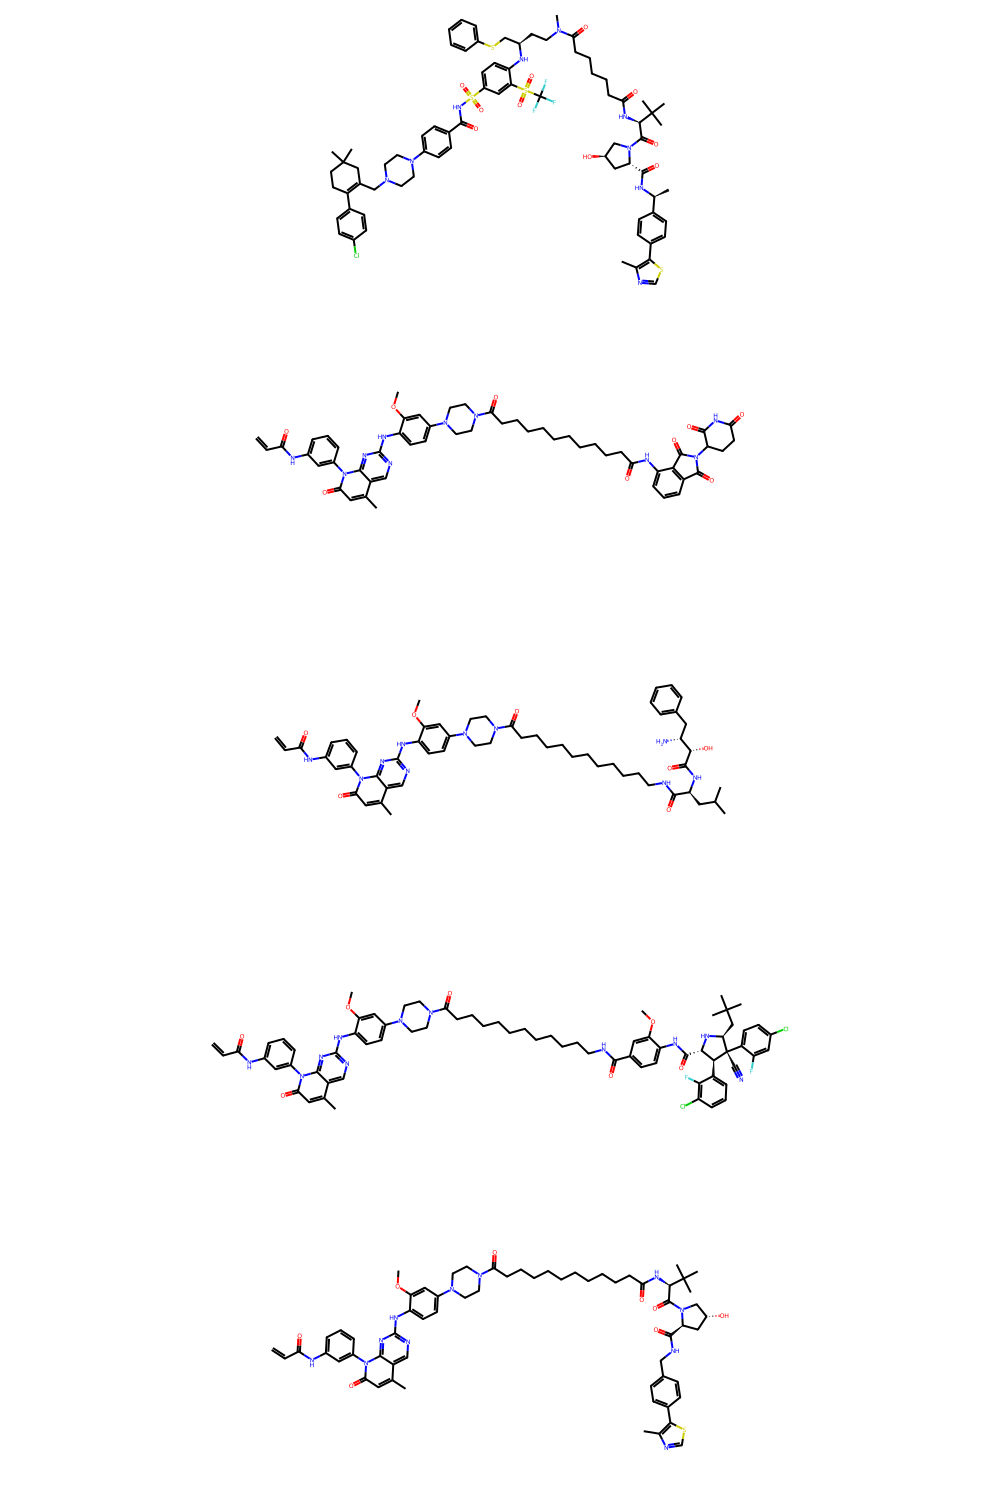

Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCC(=O)N(C)CC[C@H](CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)cc3)cc2S(=O)(=O)C(F)(F)F)C(C)(C)C)cc1
C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C(=O)CCCCCCCCCCC(=O)Nc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)cc4OC)nc32)c1
C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C(=O)CCCCCCCCCCCNC(=O)[C@H](CC(C)C)NC(=O)[C@@H](O)[C@H](N)Cc6ccccc6)CC5)cc4OC)nc32)c1
C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C(=O)CCCCCCCCCCCNC(=O)c6ccc(NC(=O)[C@@H]7N[C@@H](CC(C)(C)C)[C@](C#N)(c8ccc(Cl)cc8F)[C@H]7c7cccc(Cl)c7F)c(OC)c6)CC5)cc4OC)nc32)c1
C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C(=O)CCCCCCCCCCC(=O)N[C@H](C(=O)N6C[C@H](O)C[C@H]6C(=O)NCc6ccc(-c7scnc7C)cc6)C(C)(C)C)CC5)cc4OC)nc32)c1
----------------------------------------------------------------------------------------------------
Error type: no_poi_match
Number of PROTACs with this error: 1,171


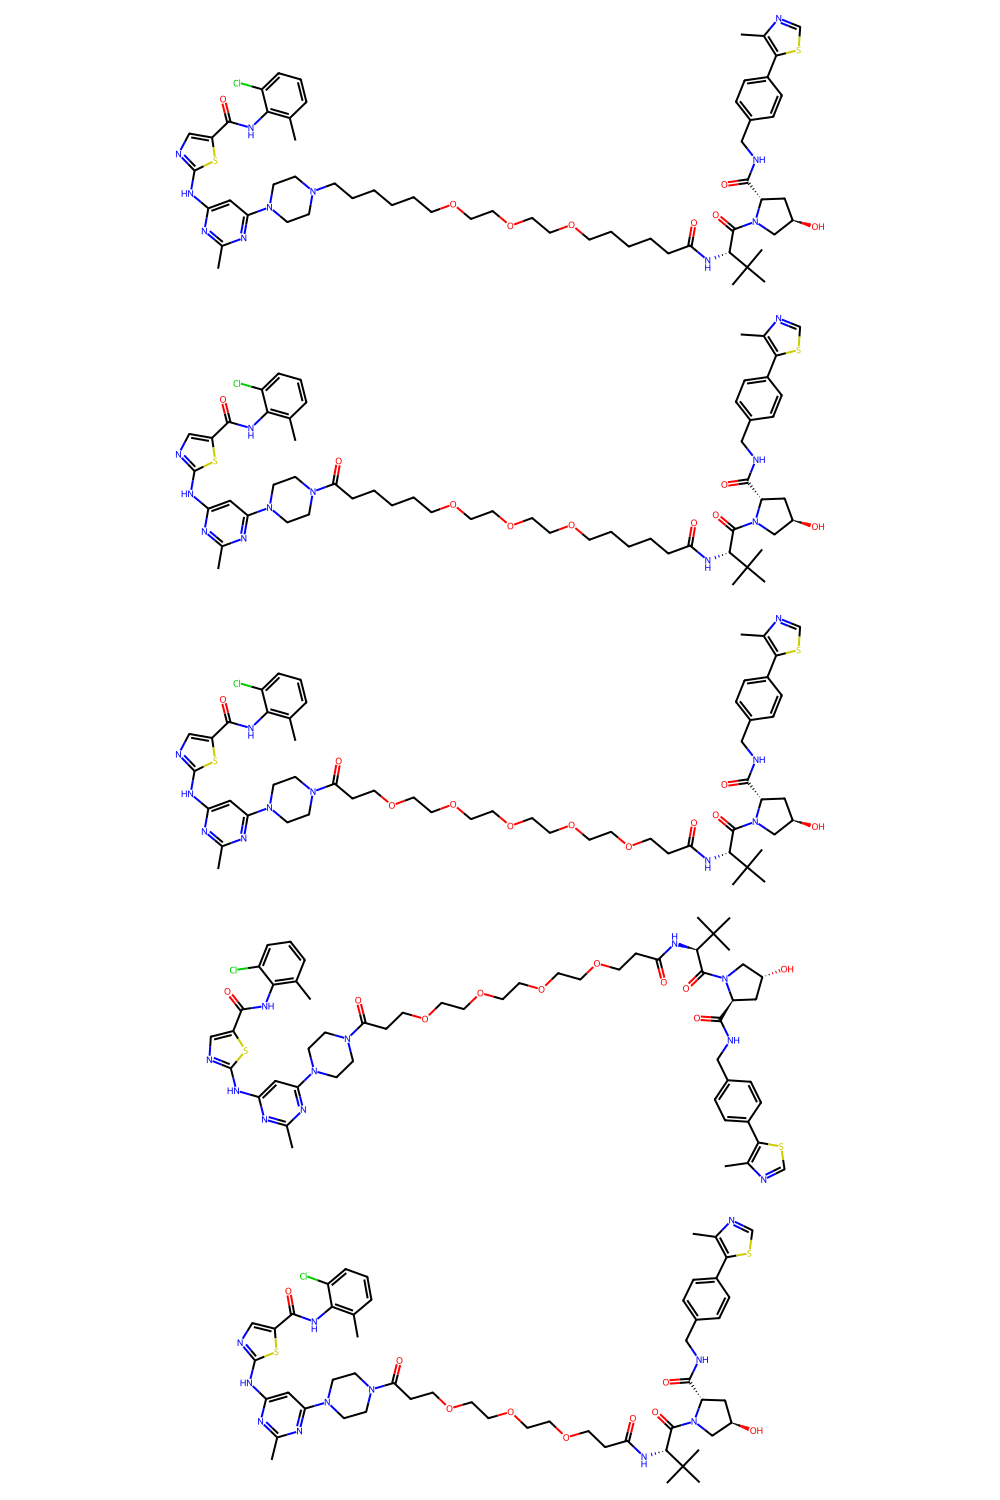

Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(CCCCCCOCCOCCOCCCCCC(=O)N[C@H](C(=O)N3C[C@H](O)C[C@H]3C(=O)NCc3ccc(-c4scnc4C)cc3)C(C)(C)C)CC2)n1
Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(C(=O)CCCCCOCCOCCOCCCCCC(=O)N[C@H](C(=O)N3C[C@H](O)C[C@H]3C(=O)NCc3ccc(-c4scnc4C)cc3)C(C)(C)C)CC2)n1
Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(C(=O)CCOCCOCCOCCOCCOCCC(=O)N[C@H](C(=O)N3C[C@H](O)C[C@H]3C(=O)NCc3ccc(-c4scnc4C)cc3)C(C)(C)C)CC2)n1
Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(C(=O)CCOCCOCCOCCOCCC(=O)N[C@H](C(=O)N3C[C@H](O)C[C@H]3C(=O)NCc3ccc(-c4scnc4C)cc3)C(C)(C)C)CC2)n1
Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(C(=O)CCOCCOCCOCCC(=O)N[C@H](C(=O)N3C[C@H](O)C[C@H]3C(=O)NCc3ccc(-c4scnc4C)cc3)C(C)(C)C)CC2)n1
----------------------------------------------------------------------------------------------------
Error type: no_e3_match
Number of PROTACs with this error: 52


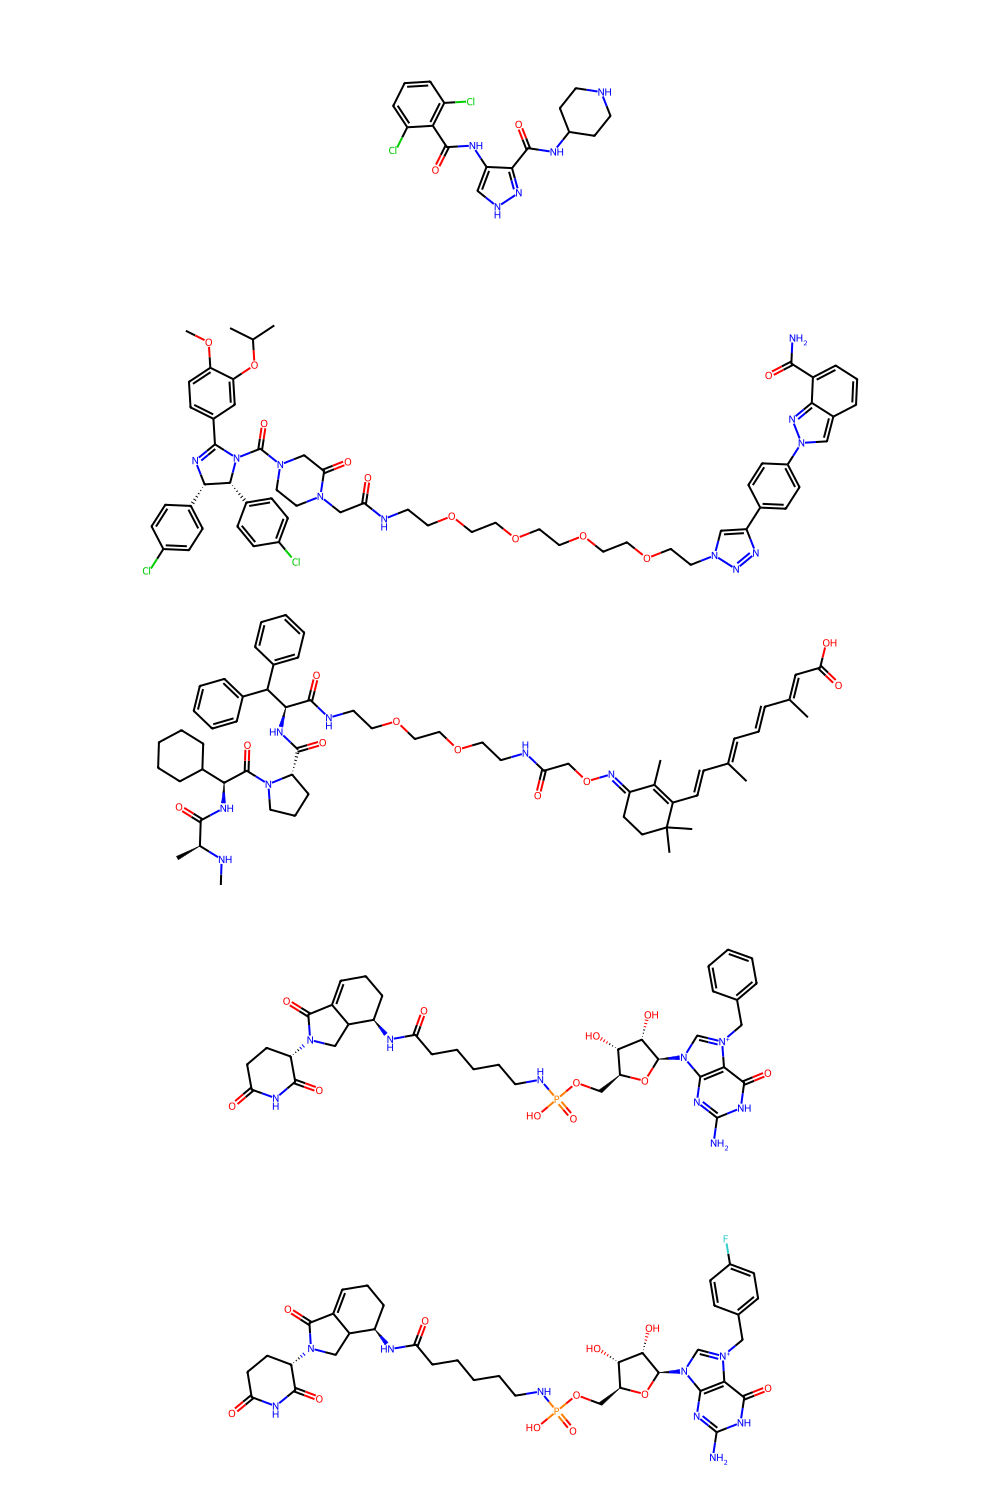

O=C(NC1CCNCC1)c1n[nH]cc1NC(=O)c1c(Cl)cccc1Cl
COc1ccc(C2=N[C@@H](c3ccc(Cl)cc3)[C@@H](c3ccc(Cl)cc3)N2C(=O)N2CCN(CC(=O)NCCOCCOCCOCCOCCn3cc(-c4ccc(-n5cc6cccc(C(N)=O)c6n5)cc4)nn3)C(=O)C2)cc1OC(C)C
CN[C@@H](C)C(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)N[C@H](C(=O)NCCOCCOCCNC(=O)CO/N=C1\CCC(C)(C)C(/C=C/C(C)=C/C=C/C(C)=C/C(=O)O)=C1C)C(c1ccccc1)c1ccccc1)C1CCCCC1
Nc1nc2c(c(=O)[nH]1)[n+](Cc1ccccc1)cn2[C@H]1O[C@@H](COP(=O)(O)NCCCCCC(=O)N[C@@H]2CCC=C3C(=O)N([C@H]4CCC(=O)NC4=O)CC32)[C@H](O)[C@@H]1O
Nc1nc2c(c(=O)[nH]1)[n+](Cc1ccc(F)cc1)cn2[C@H]1O[C@@H](COP(=O)(O)NCCCCCC(=O)N[C@@H]2CCC=C3C(=O)N([C@H]4CCC(=O)NC4=O)CC32)[C@H](O)[C@@H]1O
----------------------------------------------------------------------------------------------------
Error type: multiple * in R-Group=PROTAC-POI
Number of PROTACs with this error: 51


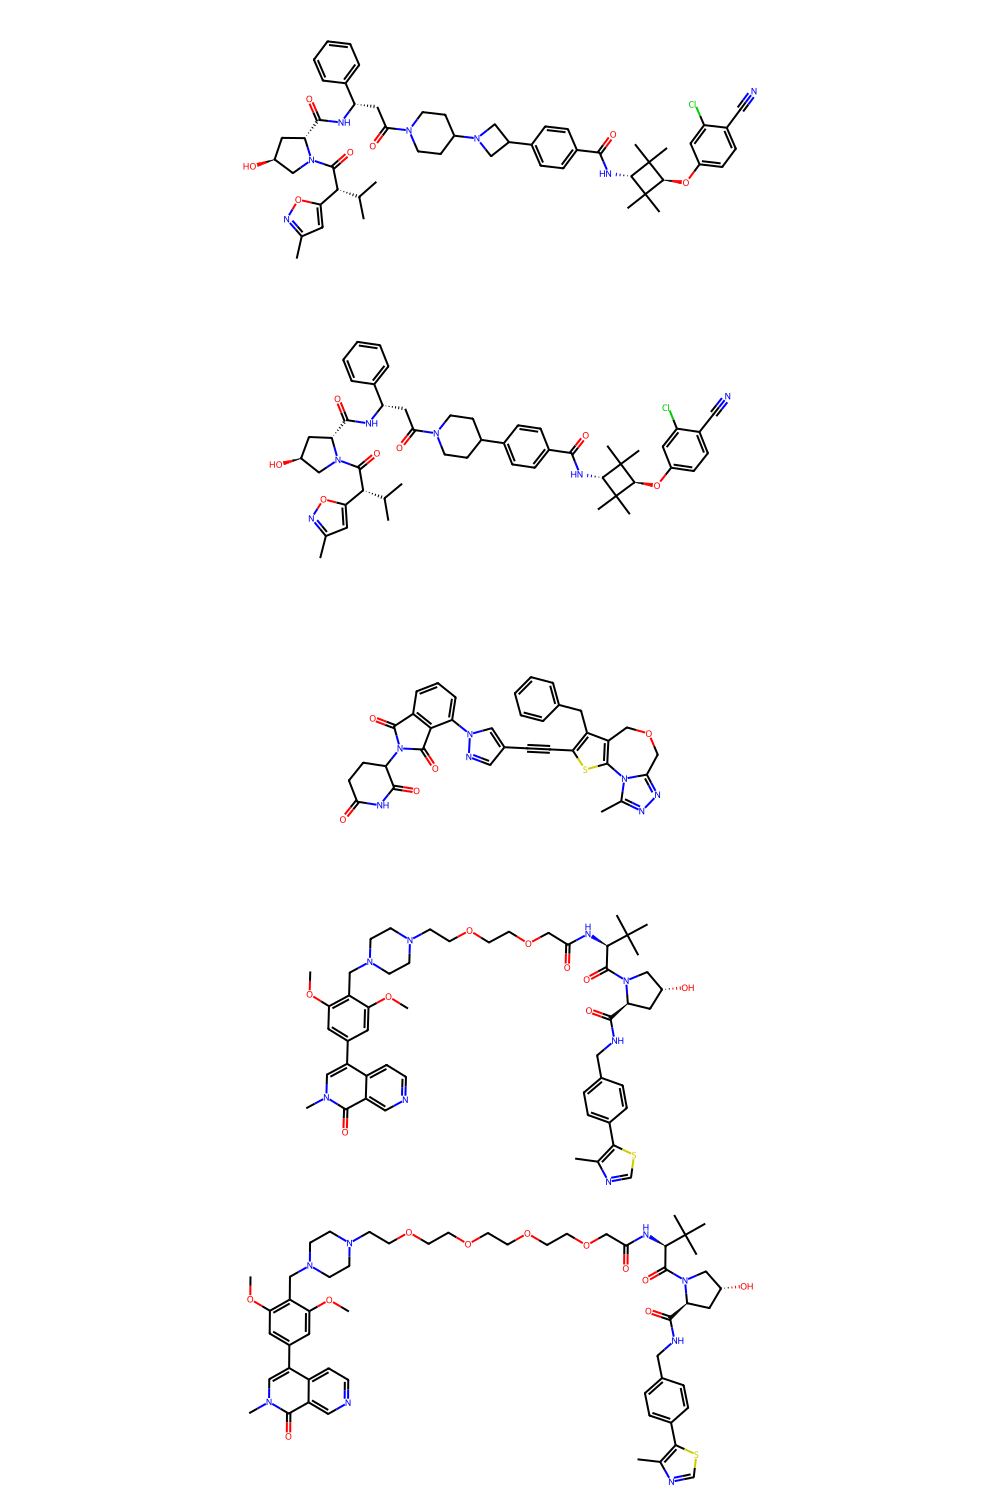

Cc1cc([C@H](C(=O)N2C[C@@H](O)C[C@@H]2C(=O)N[C@@H](CC(=O)N2CCC(N3CC(c4ccc(C(=O)N[C@H]5C(C)(C)[C@H](Oc6ccc(C#N)c(Cl)c6)C5(C)C)cc4)C3)CC2)c2ccccc2)C(C)C)on1
Cc1cc([C@H](C(=O)N2C[C@@H](O)C[C@@H]2C(=O)N[C@@H](CC(=O)N2CCC(c3ccc(C(=O)N[C@H]4C(C)(C)[C@H](Oc5ccc(C#N)c(Cl)c5)C4(C)C)cc3)CC2)c2ccccc2)C(C)C)on1
Cc1nnc2n1-c1sc(C#Cc3cnn(-c4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)c3)c(Cc3ccccc3)c1COC2
COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(CCOCCOCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)(C)C)CC1
COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(CCOCCOCCOCCOCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)(C)C)CC1
----------------------------------------------------------------------------------------------------
Error type: e3_dangling_groups
Number of PROTACs with this error: 33


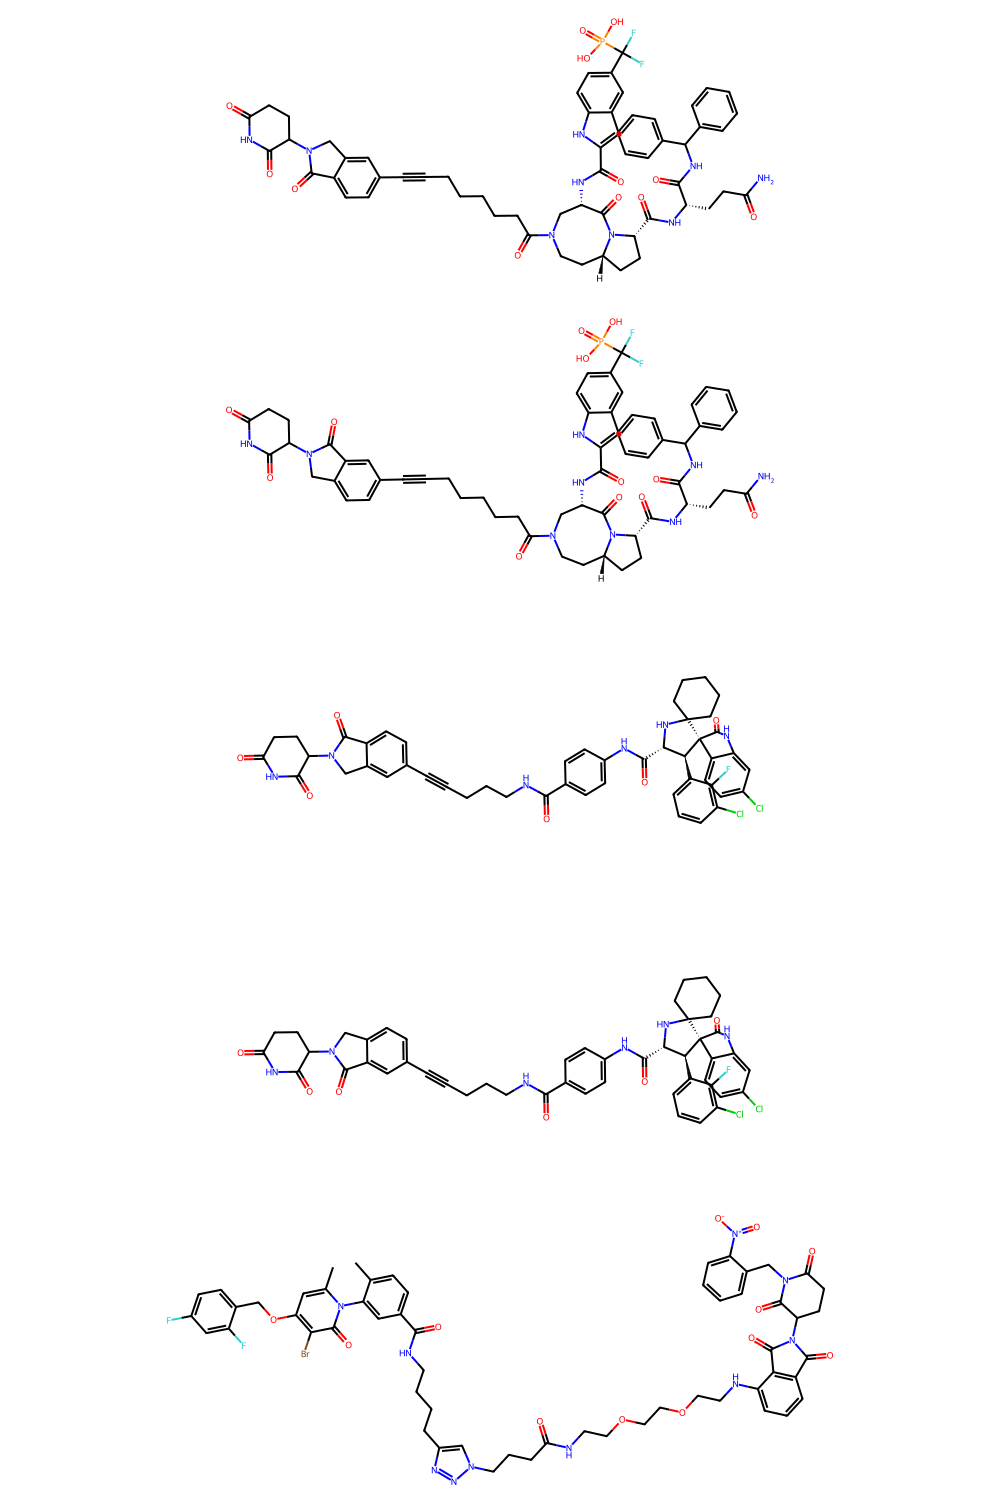

NC(=O)CC[C@H](NC(=O)[C@@H]1CC[C@@H]2CCN(C(=O)CCCCCC#Cc3ccc4c(c3)CN(C3CCC(=O)NC3=O)C4=O)C[C@H](NC(=O)c3cc4cc(C(F)(F)P(=O)(O)O)ccc4[nH]3)C(=O)N21)C(=O)NC(c1ccccc1)c1ccccc1
NC(=O)CC[C@H](NC(=O)[C@@H]1CC[C@@H]2CCN(C(=O)CCCCCC#Cc3ccc4c(c3)C(=O)N(C3CCC(=O)NC3=O)C4)C[C@H](NC(=O)c3cc4cc(C(F)(F)P(=O)(O)O)ccc4[nH]3)C(=O)N21)C(=O)NC(c1ccccc1)c1ccccc1
O=C1CCC(N2Cc3cc(C#CCCCNC(=O)c4ccc(NC(=O)[C@@H]5NC6(CCCCC6)[C@@]6(C(=O)Nc7cc(Cl)ccc76)[C@H]5c5cccc(Cl)c5F)cc4)ccc3C2=O)C(=O)N1
O=C1CCC(N2Cc3ccc(C#CCCCNC(=O)c4ccc(NC(=O)[C@@H]5NC6(CCCCC6)[C@@]6(C(=O)Nc7cc(Cl)ccc76)[C@H]5c5cccc(Cl)c5F)cc4)cc3C2=O)C(=O)N1
Cc1ccc(C(=O)NCCCCc2cn(CCCC(=O)NCCOCCOCCNc3cccc4c3C(=O)N(C3CCC(=O)N(Cc5ccccc5[N+](=O)[O-])C3=O)C4=O)nn2)cc1-n1c(C)cc(OCc2ccc(F)cc2F)c(Br)c1=O
----------------------------------------------------------------------------------------------------
Error type: rgroup_not_match_e3
Number of PROTACs with this error: 12


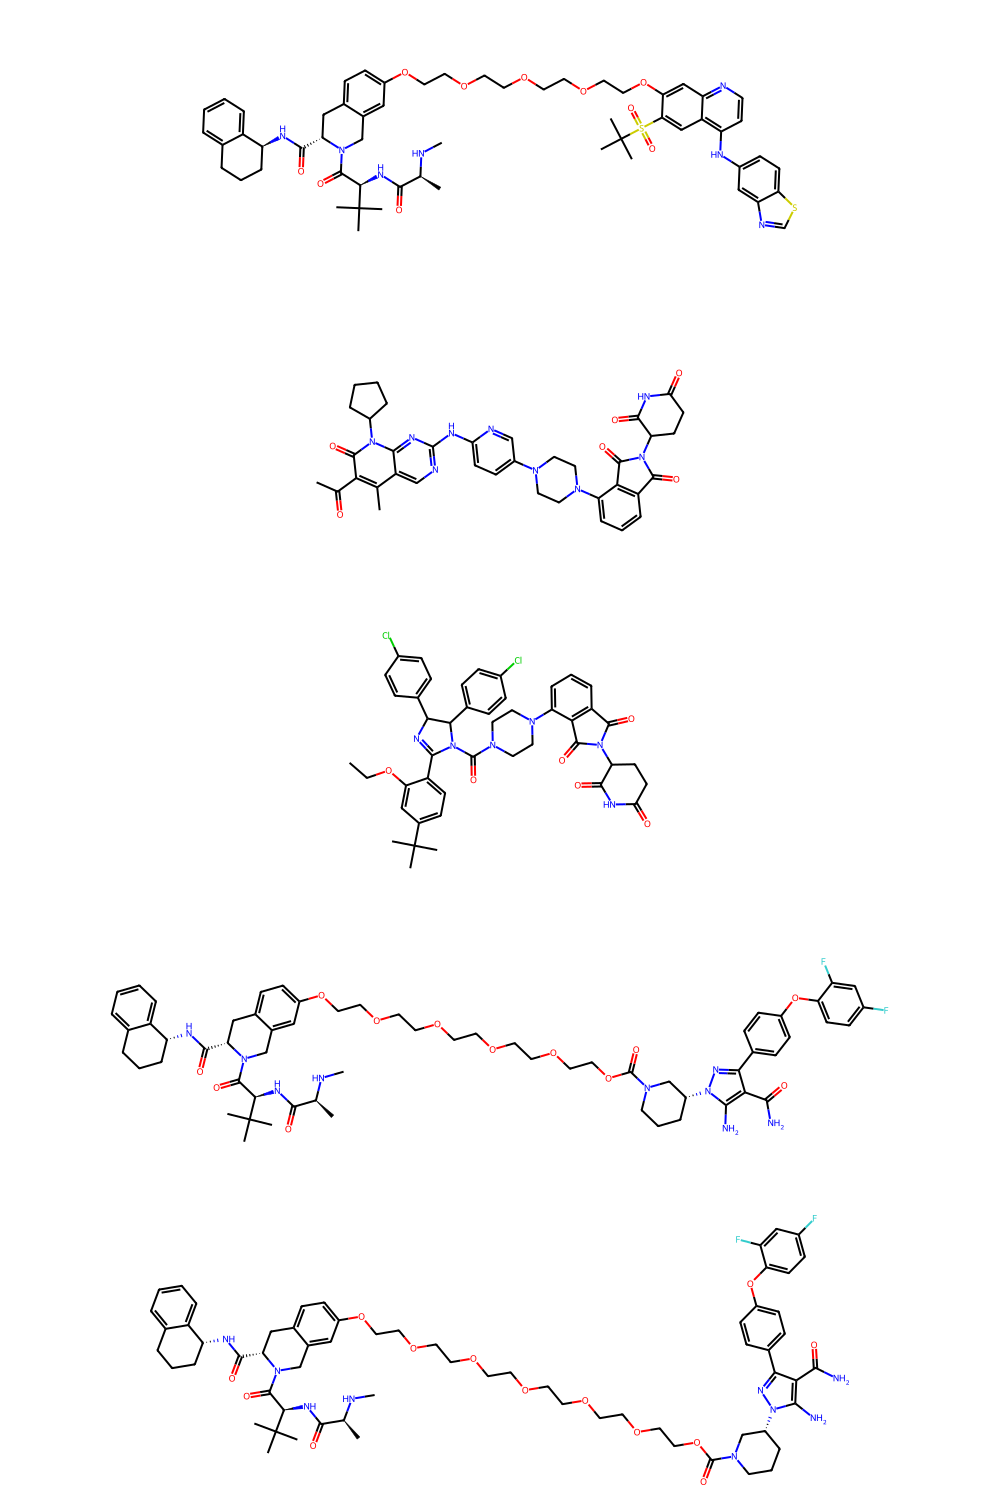

CN[C@@H](C)C(=O)N[C@H](C(=O)N1Cc2cc(OCCOCCOCCOCCOc3cc4nccc(Nc5ccc6scnc6c5)c4cc3S(=O)(=O)C(C)(C)C)ccc2C[C@H]1C(=O)N[C@H]1CCCc2ccccc21)C(C)(C)C
CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCN(c5cccc6c5C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cn3)nc2n(C2CCCC2)c1=O
CCOc1cc(C(C)(C)C)ccc1C1=NC(c2ccc(Cl)cc2)C(c2ccc(Cl)cc2)N1C(=O)N1CCN(c2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)CC1
CN[C@@H](C)C(=O)N[C@H](C(=O)N1Cc2cc(OCCOCCOCCOCCOCCOC(=O)N3CCC[C@@H](n4nc(-c5ccc(Oc6ccc(F)cc6F)cc5)c(C(N)=O)c4N)C3)ccc2C[C@H]1C(=O)N[C@@H]1CCCc2ccccc21)C(C)(C)C
CN[C@@H](C)C(=O)N[C@H](C(=O)N1Cc2cc(OCCOCCOCCOCCOCCOCCOC(=O)N3CCC[C@@H](n4nc(-c5ccc(Oc6ccc(F)cc6F)cc5)c(C(N)=O)c4N)C3)ccc2C[C@H]1C(=O)N[C@@H]1CCCc2ccccc21)C(C)(C)C
----------------------------------------------------------------------------------------------------


In [118]:
# For each error type in failed_protacs_df, draw a large image of the first 10 PROTACs
# that failed with that error type
show_top_n = 5

for error_type in failed_protacs_df['error'].unique():
    failed_protacs_df_error = failed_protacs_df[failed_protacs_df['error'] == error_type]

    print(f'Error type: {error_type}')
    print(f'Number of PROTACs with this error: {len(failed_protacs_df_error):,}')

    failed_protacs_df_error = failed_protacs_df_error.head(show_top_n)

    # Use RDKit to draw the molecules
    mols = []
    for i, row in failed_protacs_df_error.iterrows():
        mols.append(Chem.MolFromSmiles(row['PROTAC SMILES']))
    img = Draw.MolsToGridImage(mols, molsPerRow=1, subImgSize=(1000, 300))
    safe_display(img)

    # Print the SMILES
    for i, row in failed_protacs_df_error.iterrows():
        print(row['PROTAC SMILES'])

    print('-' * 100)

Double check that all substructures can be re-assembled into the original PROTACs:

In [73]:
def check_dataframe(df: pd.DataFrame) -> pd.Series:
    tqdm.pandas(desc='Checking dataframe')
    return df.progress_apply(lambda x: check_substructs(
            protac_smiles=x['PROTAC SMILES'],
            poi_smiles=x['POI Ligand SMILES with direction'],
            linker_smiles=x['Linker SMILES with direction'],
            e3_smiles=x['E3 Binder SMILES with direction'],
        ), axis=1)

print('Number of incorrect re-assembled samples:', len(protac_curated_df[~check_dataframe(protac_curated_df)]))

Checking dataframe: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2337/2337 [00:20<00:00, 112.56it/s]

Number of incorrect re-assembled samples: 0


## Add Removed Stereochemistry PROTACs

In [74]:
tqdm.pandas(desc='Removing stereochemistry', postfix=None)

pedia_nostereo_df = protac_pedia_df.copy()
pedia_nostereo_df['PROTAC SMILES'] = pedia_nostereo_df['PROTAC SMILES'].progress_apply(remove_stereo)
pedia_nostereo_df = pedia_nostereo_df.dropna(subset=['PROTAC SMILES'])

db_nostereo_df = protac_db_df.copy()
db_nostereo_df['PROTAC SMILES'] = db_nostereo_df['PROTAC SMILES'].progress_apply(remove_stereo)
db_nostereo_df = db_nostereo_df.dropna(subset=['PROTAC SMILES'])

poi_dict = smiles2id_df['POI Ligand'].copy()
e3_dict = smiles2id_df['E3 Binder'].copy()

Removing stereochemistry:   0%|                                                                                                                                                                                                                                                                                                                    | 0/1203 [00:00<?, ?it/s]

Removing stereochemistry: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5388/5388 [00:03<00:00, 1661.85it/s]


In [75]:
pedia = pedia_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])
db = db_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])
curated_nostereo_df = pd.concat([db, pedia], axis=0, ignore_index=True)
curated_nostereo_df = curated_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])

# Get all entries with SMILES not in protac_curated_df
curated_nostereo_df = curated_nostereo_df[~curated_nostereo_df['PROTAC SMILES'].isin(protac_curated_df['PROTAC SMILES'])]

tqdm.pandas(desc='Get substructures', postfix=None)
curated_nostereo_df = curated_nostereo_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
curated_nostereo_df = curated_nostereo_df.dropna(subset=dir_cols)

# ------------------------------------------------------------------------------

# print(f'Length of PROTAC-Pedia: {len(pedia_nostereo_df)}')
# tqdm.pandas(desc='Get substructures for PROTAC-Pedia', postfix=None)
# pedia = pedia_nostereo_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
# pedia = pedia.dropna(subset=smi_cols)
# print(f'Length of PROTAC-Pedia: {len(pedia)} (after substructure matching)')

# print(f'Length of PROTAC-DB: {len(db_nostereo_df)}')
# tqdm.pandas(desc='Get substructures for PROTAC-DB', postfix=None)
# db = db_nostereo_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
# db = db.dropna(subset=smi_cols)
# print(f'Length of PROTAC-DB: {len(db)} (after substructure matching)')

# # NOTE: protac_pedia_curated_df is the DataFrame with the curated PROTAC-Pedia
# # entries that matched already with its entries
# curated_nostereo_df = pd.concat([db, pedia], axis=0, ignore_index=True)
# curated_nostereo_df = curated_nostereo_df.dropna(subset=dir_cols)

# ------------------------------------------------------------------------------

safe_display(curated_nostereo_df[smi_cols].head())
safe_display(curated_nostereo_df[dir_cols].head())
print(f'Length of PROTAC-Curated: {len(curated_nostereo_df)} (without stereochemistry)')

Get substructures: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2727/2727 [01:39<00:00, 27.31it/s]


,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES
47,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,CCC,CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(...
53,CC(=O)N[C@@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@...,CC,CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(...
54,CC(=O)N[C@@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@...,COCCOC,CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(...
55,CC(=O)N[C@@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@...,COCCOCCOC,CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(...
111,CNC(=O)C[C@H](NC(=O)[C@H]1C[C@H](O)CN1C(=O)[C@...,CCCCCCC,CNC(=O)c1ccc(N2C(=S)N(c3ccc(C#N)c(C(F)(F)F)c3)...


,E3 Binder SMILES with direction,Linker SMILES with direction,POI Ligand SMILES with direction
47,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,[*:2]CCC[*:1],O=C(NC[*:1])c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)N...
53,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=...,[*:2]CC[*:1],O=C(NC[*:1])c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)N...
54,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=...,[*:2]COCCOC[*:1],O=C(NC[*:1])c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)N...
55,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=...,[*:2]COCCOCCOC[*:1],O=C(NC[*:1])c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)N...
111,Cc1cc(C(C(=O)N2CC(O)CC2C(=O)NC(CC(=O)NC[*:2])c...,[*:2]CCCCCCC[*:1],CC1(C)C(=O)N(c2ccc(C#N)c(C(F)(F)F)c2)C(=S)N1c1...


Length of PROTAC-Curated: 233 (without stereochemistry)


Double check that all substructures can be re-assembled into the original PROTACs:

In [76]:
print('Number of incorrect re-assembled samples:', len(curated_nostereo_df[~check_dataframe(curated_nostereo_df)]))

Checking dataframe:   0%|                                                                                                                                                                                                                                                                                                                           | 0/233 [00:00<?, ?it/s]

Checking dataframe: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 233/233 [00:02<00:00, 78.95it/s]

Number of incorrect re-assembled samples: 0


## Remove Duplicates

Check if there are and how any duplicates look like in the PROTAC SMIILES column:

In [77]:
print(f'Number of duplicates in PROTAC SMILES: {protac_curated_df["PROTAC SMILES"].duplicated().sum()}')

# Display duplicated PROTACs and their substructures
i = 0
for protac_smiles, group in protac_curated_df.drop_duplicates(subset=dir_cols).groupby("PROTAC SMILES"):
    # Reset index and print every row in the group
    group = group.reset_index().drop_duplicates(subset=smiles_cols + dir_cols)
    if len(group) == 1:
        continue
    print(f'PROTAC: {protac_smiles}')
    print("-" * 80)
    for c in dir_cols:
        for s in group[c].unique():
            print(f'\t{c.capitalize().split(" ")[0]}:\t{s}')
        print('')
    print("=" * 80)
    print('')
    i += 1
    if i > 10:
        break

Number of duplicates in PROTAC SMILES: 419


Let's remove duplicates for the same PROTAC, by keeping the entry with the longest SMILES (in terms of atoms):

In [78]:
substruct_smiles_cols = [
    'POI Ligand SMILES',
    'Linker SMILES',
    'E3 Binder SMILES',
]
relevant_cols = substruct_smiles_cols + dir_cols

final_df = pd.concat([protac_curated_df, curated_nostereo_df], axis=0, ignore_index=True)

no_duplicates_df = []
no_duplicates_sr = []
i = 0
for protac_smiles, group in final_df.groupby("PROTAC SMILES"):
    # Reset index and print every row in the group
    if len(group) == 1:
        no_duplicates_df.append(group.copy())
        continue

    # if i < 5:
    #     print(f'PROTAC: {protac_smiles}')
    #     display(group)
    #     display(group.reset_index().drop_duplicates(subset=dir_cols))
    #     print('-' * 80)
    # group = group.reset_index().drop_duplicates(subset=dir_cols)

    # Loop over the rows in the group to get the one with the longest linker
    max_atoms = 0
    row_w_longest_linker = None
    for j, row in group.iterrows():
        # Get the number of atoms in the linker substructures
        linker_mol = Chem.MolFromSmiles(row["Linker SMILES with direction"])
        num_atoms = Chem.rdMolDescriptors.CalcNumHeavyAtoms(linker_mol)
        # NOTE: We leave in empty linkers (i.e., with no atoms)
        if num_atoms >= max_atoms:
            max_atoms = num_atoms
            row_w_longest_linker = row.copy()
            if i < 5:
                print(f'Linker n.{j}: {row["Linker SMILES with direction"]}')

    # if row_w_longest_linker is None:
    #     safe_display(group.iloc[0]['PROTAC SMILES'])
    #     safe_display(group.iloc[0]['POI Ligand SMILES with direction'])
    #     safe_display(group.iloc[1]['POI Ligand SMILES with direction'])
    #     safe_display(group[dir_cols])

    if i < 5:
        print(f'Linker with max atoms: {row_w_longest_linker["Linker SMILES with direction"]} ({max_atoms} atoms)')
        print('')
    # Append the row with the longest linker
    no_duplicates_sr.append(row_w_longest_linker.copy())
    i += 1

# Concatenate the DataFrames
final_no_duplicates_df = pd.concat(no_duplicates_df, axis=0, ignore_index=True)
final_no_duplicates_sr = pd.DataFrame(no_duplicates_sr)
final_no_duplicates_df = pd.concat([final_no_duplicates_df, final_no_duplicates_sr], axis=0, ignore_index=True)

print(f'Lenght before removing duplicates: {len(final_df)}')
num_duplicates = final_df["PROTAC SMILES"].duplicated().sum()
print(f'Number of duplicates in PROTAC SMILES: {num_duplicates}')
print(f'Length after removal: {len(final_no_duplicates_df)} (Expected: {len(final_df) - num_duplicates})')

final_no_duplicates_df = final_no_duplicates_df.dropna(subset=dir_cols)
print(f'Length after dropna: {len(final_no_duplicates_df)}')

final_no_duplicates_df = final_no_duplicates_df.drop_duplicates(subset='PROTAC SMILES')
print(f'Length after drop_duplicates: {len(final_no_duplicates_df)}')

num_duplicates = final_no_duplicates_df["PROTAC SMILES"].duplicated().sum()
print(f'Number of duplicates in PROTAC SMILES: {num_duplicates}')
final_no_duplicates_df.head()[dir_cols]

Linker n.938: [*:2]CNC(=O)C[*:1]
Linker n.2177: [*:2]CNC(=O)C[*:1]
Linker with max atoms: [*:2]CNC(=O)C[*:1] (5 atoms)

Linker n.941: [*:2]COCCNC(=O)C[*:1]
Linker n.2180: [*:2]COCCNC(=O)C[*:1]
Linker with max atoms: [*:2]COCCNC(=O)C[*:1] (8 atoms)

Linker n.936: [*:2]COCCOCCNC(=O)C[*:1]
Linker n.2175: [*:2]COCCOCCNC(=O)C[*:1]
Linker with max atoms: [*:2]COCCOCCNC(=O)C[*:1] (11 atoms)

Linker n.939: [*:2]COCCC[*:1]
Linker n.2178: [*:2]COCCC[*:1]
Linker with max atoms: [*:2]COCCC[*:1] (5 atoms)

Linker n.937: [*:2]COCC[*:1]
Linker n.2176: [*:2]COCC[*:1]
Linker with max atoms: [*:2]COCC[*:1] (4 atoms)

Lenght before removing duplicates: 2570
Number of duplicates in PROTAC SMILES: 419
Length after removal: 2151 (Expected: 2151)
Length after dropna: 2151
Length after drop_duplicates: 2151
Number of duplicates in PROTAC SMILES: 0


,E3 Binder SMILES with direction,Linker SMILES with direction,POI Ligand SMILES with direction
0,Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C...,[*:2]OCCOCC[*:1],C=CC(=O)N1CC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)n...
1,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1,[*:2]C(=O)COCCOCC[*:1],C=CC(=O)N1CC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)n...
2,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1,[*:2]C(=O)COCCOCCOCC[*:1],C=CC(=O)N1CC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)n...
3,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1,[*:2]C(=O)COCCOCCOCCOCC[*:1],C=CC(=O)N1CC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)n...
4,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1,[*:2]C(=O)COCCOCCOCCOCCOCC[*:1],C=CC(=O)N1CC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)n...


## Cleanup Dummy Atoms

Some of the dummy atoms entries might not be "perfect", _e.g._, instead of `[*:1]` they might be `[1:*1]`. Let's fix this:

In [79]:
# For each substructure column with direction, check the dummy atoms with a
# regex, i.e, if there is a '*' within [] brackets: if there are not [*:1] nor [*:2],
# convert them to the correct attachment points.
dummy_rgx = re.compile(r'\[\*[\:\d+]*\]')

for col in dir_cols:
    print('-' * 80)
    print(f'Checking {col}')
    print('-' * 80)
    for smiles in final_no_duplicates_df[col].unique():
        if not dummy_rgx.search(smiles):
            print(f'ERROR: No dummy atoms found in: {smiles}')
        for match in dummy_rgx.finditer(smiles):
            # Check if match not equal to '[*:1]' nor '[*:2]'
            if match.group() not in ['[*:1]', '[*:2]']:
                new_smiles = smiles.replace(match.group(), f'[*:{match.group(1)}]')
                print(f'{smiles} -> {new_smiles}')
            # final_no_duplicates_df[col] = final_no_duplicates_df[col].replace(smiles, new_smiles)

--------------------------------------------------------------------------------
Checking E3 Binder SMILES with direction
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
Checking Linker SMILES with direction
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
Checking POI Ligand SMILES with direction
--------------------------------------------------------------------------------


In [80]:
print(f'Lenght of final_no_duplicates_df: {len(final_no_duplicates_df)}')
final_no_duplicates_df.head()[relevant_cols]

Lenght of final_no_duplicates_df: 2151


,POI Ligand SMILES,Linker SMILES,E3 Binder SMILES,E3 Binder SMILES with direction,Linker SMILES with direction,POI Ligand SMILES with direction
0,C=CC(=O)N1C[C@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c...,OCCOCC,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1c...,Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C...,[*:2]OCCOCC[*:1],C=CC(=O)N1CC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)n...
1,C=CC(=O)N1C[C@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c...,C(=O)COCCOCC,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1,[*:2]C(=O)COCCOCC[*:1],C=CC(=O)N1CC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)n...
2,C=CC(=O)N1C[C@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c...,C(=O)COCCOCCOCC,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1,[*:2]C(=O)COCCOCCOCC[*:1],C=CC(=O)N1CC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)n...
3,C=CC(=O)N1C[C@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c...,C(=O)COCCOCCOCCOCC,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1,[*:2]C(=O)COCCOCCOCCOCC[*:1],C=CC(=O)N1CC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)n...
4,C=CC(=O)N1C[C@H](n2nc(-c3ccc(Oc4ccccc4)cc3)c3c...,C(=O)COCCOCCOCCOCCOCC,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1,[*:2]C(=O)COCCOCCOCCOCCOCC[*:1],C=CC(=O)N1CC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)n...


In [25]:
print('Number of incorrect re-assembled samples:', len(final_no_duplicates_df[~check_dataframe(final_no_duplicates_df)]))

Checking dataframe:   0%|                                                                                                                                                                                                                                                                                                                          | 0/1926 [00:00<?, ?it/s]

Checking dataframe: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1926/1926 [00:16<00:00, 119.02it/s]

Number of incorrect re-assembled samples: 0


## Add Missing IDs

In [81]:
def add_to_dict(
        smiles: str,
        smiles2id_dict: Dict[str, Dict[str, int]],
        substruct: str,
) -> Dict[str, Dict[str, int]]:
    """ Add a SMILES to an ID dictionary.

    Args:
        smiles (str): The SMILES to add to the dictionary.
        smiles2id_dict (Dict[str, Dict[str, int]]): The dictionary with the SMILES to ID mapping.
        substruct (str): The column name of the dictionary to add the SMILES to.

    Returns:
        Dict[str, Dict[str, int]]: The updated dictionary.
    """
    if smiles not in smiles2id_dict[substruct]:
        smiles2id_dict[substruct][smiles] = len(smiles2id_dict[substruct])
    return smiles2id_dict

print('Updating the dictionaries...')
for substruct, smiles2id in smiles2id_dict.items():
    print(f'{substruct}: {len(smiles2id)}')

for substruct, smiles2id in smiles2id_dict.items():
    smi_col = f'{substruct} SMILES'
    smi_id_col = f'{substruct} ID'
    for smi, smi_id in zip(final_no_duplicates_df[smi_col], final_no_duplicates_df[smi_id_col]):
        if pd.isnull(smi_id):
            smiles2id_dict = add_to_dict(smi, smiles2id_dict, substruct)

print('-' * 80)
for substruct, smiles2id in smiles2id_dict.items():
    print(f'{substruct}: {len(smiles2id)}')

Updating the dictionaries...
PROTAC: 5680
POI Ligand: 871
Linker: 4249
E3 Binder: 257
--------------------------------------------------------------------------------
PROTAC: 5680
POI Ligand: 871
Linker: 4249
E3 Binder: 257


In [83]:
for substruct in ['PROTAC', 'E3 Binder', 'Linker', 'POI Ligand']:
    smiles2id = smiles2id_dict[substruct]
    final_no_duplicates_df[f'{substruct} ID'] = final_no_duplicates_df[f'{substruct} SMILES'].apply(lambda x: smiles2id.get(x, float('nan')))
    final_no_duplicates_df[f'{substruct} ID'] = final_no_duplicates_df[f'{substruct} ID'].apply(lambda x: x if pd.isnull(x) else int(x))

# Display rows with NaN values in the relevant columns
final_no_duplicates_df[final_no_duplicates_df[relevant_cols].isnull().any(axis=1)][relevant_cols + smi_cols]

,POI Ligand SMILES,Linker SMILES,E3 Binder SMILES,E3 Binder SMILES with direction,Linker SMILES with direction,POI Ligand SMILES with direction,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES


In [84]:
print('Number of incorrect re-assembled samples:', len(final_no_duplicates_df[~check_dataframe(final_no_duplicates_df)]))

Checking dataframe: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2151/2151 [00:19<00:00, 111.02it/s]

Number of incorrect re-assembled samples: 0


## Save to CSV

In [85]:
# Make dir if not existing
os.makedirs(os.path.join(data_dir, 'processed'), exist_ok=True)
relevant_cols = [
    'PROTAC ID',
    'PROTAC SMILES',
    'E3 Binder ID',
    'E3 Binder SMILES',
    'E3 Binder SMILES with direction',
    'Linker ID',
    'Linker SMILES',
    'Linker SMILES with direction',
    'POI Ligand ID',
    'POI Ligand SMILES',
    'POI Ligand SMILES with direction',
]
final_filename = os.path.join(data_dir, 'processed', 'protacs_splitted_with_directionality.csv')
final_no_duplicates_df[relevant_cols].to_csv(final_filename, index=False, encoding='utf8')

# Get all unique PROTACs from PROTAC-DB and PROTAC-Pedia, then save the ones
# that are NOT in the final_no_duplicates_df PROTAC SMILES
db_unique = protac_db_df.drop_duplicates(subset=['PROTAC SMILES'])
pedia_unique = protac_pedia_df.drop_duplicates(subset=['PROTAC SMILES'])
pedia_nostereo_unique = pedia_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])
db_nostereo_unique = db_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])

# Get the PROTACs that are not in the final_no_duplicates_df
tmp = pd.concat([
    db_unique,
    pedia_unique,
    pedia_nostereo_unique,
    db_nostereo_unique,
], axis=0, ignore_index=True).dropna(subset=['PROTAC SMILES'])
tmp = tmp.drop_duplicates(subset=['PROTAC SMILES'])
tmp = tmp[~tmp['PROTAC SMILES'].isin(final_no_duplicates_df['PROTAC SMILES'])]
tmp['PROTAC ID'] = tmp.apply(lambda x: smiles2id_dict['PROTAC'].get(x['PROTAC SMILES'], float('nan')), axis=1)
tmp = tmp[['PROTAC SMILES', 'PROTAC ID']]
# Save to CSV
not_splitted_filename = os.path.join(data_dir, 'processed', 'protacs_not_splitted.csv')
tmp.to_csv(not_splitted_filename, index=False, encoding='utf8')

# Reporting
print(f'Length of splitted PROTACs: {len(final_no_duplicates_df):,}')
print(f'Length of not splitted PROTACs: {len(tmp):,}')

Length of splitted PROTACs: 2,151
Length of not splitted PROTACs: 3,529


In [76]:
max_combinations = 1
# Save the dictionaries as CSV (from dataframes)
for substruct, smiles2id in smiles2id_dict.items():
    df = dict2df(smiles2id, substruct)
    substruct_name = substruct.split(' ')[0].lower()
    filename = os.path.join(data_dir, 'processed', f'dictionary_{substruct_name}.csv')
    df.to_csv(filename, index=False, encoding='utf8')
    print(f'Length of {substruct} dictionary: {len(df):,}')
    if substruct != 'PROTAC':
        max_combinations *= len(df)
print(f'Maximum number of PROTAC combinations: {max_combinations:,} ({len(smiles2id_dict["PROTAC"]) / max_combinations:%} covered)')

Length of PROTAC dictionary: 5,680
Length of POI Ligand dictionary: 871
Length of Linker dictionary: 4,108
Length of E3 Binder dictionary: 257
Maximum number of PROTAC combinations: 919,563,476 (0.000618% covered)
